# PySpatialStats

**[PySpatialStats](https://github.com/zia207/PySpatialStats)** - a unified Python package for geographically weighted modelling.

This notebook is the **official introduction** for PySpatialStats: it explains the theory behind each method, builds a minimal GWR engine from NumPy so every equation has a line of code, and maps each model to its `spatialstats.gwmodel` class and module.

| Install | Command |
|---|---|
| Core | `pip install pyspatialstats` |
| Deep learning | `pip install pyspatialstats[deep]` |
| Boosting | `pip install pyspatialstats[boosting]` |
| Everything | `pip install pyspatialstats[all]` |




In [2]:
# ---------------------------------------------------------------
# Environment
# ---------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy import stats

# PySpatialStats — production implementations (imported as PyGWR etc. to avoid
# clashing with the scratch GWR class built in Section 2.4)
import spatialstats.gwmodel as pygwmodel
from spatialstats.gwmodel.linear import GWR as PyGWR, MGWR as PyMGWR
from spatialstats.gwmodel.utils.compute import set_compute_options

set_compute_options(n_jobs=-1)  # use all CPU cores for local fits

np.random.seed(42)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

print("PySpatialStats", pygwmodel.__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)

PySpatialStats 0.1.0
numpy 2.4.6 | pandas 3.0.3


<a id="0"></a>
# 0. PySpatialStats at a Glance

**PySpatialStats** (`spatialstats.gwmodel`) is a comprehensive Python package that implements the full geographically weighted model family in one consistent API — classical linear models, multiscale GWR, GW machine learning, deep neural weighting, multivariate GWPCA, and network-constrained GWR.

## Package layout

```
spatialstats/gwmodel/
├── core/           # kernels, bandwidth selection, base classes
├── linear/         # GWR, MGWR, GWGLM, GWSS, MixedGWR
├── spatiotemporal/ # GTWR
├── ensemble/       # GWRandomForest, GWXGBoost, GWLightGBM
├── deep/           # GNNWR, GTNNWR (PyTorch)
├── multivariate/   # GWPCA
├── network/        # NetworkGWR
├── diagnostics/    # collinearity, heterogeneity, Moran's I
├── visualization/  # coefficient & importance maps
├── datasets/       # load_georgia(), load_londonhouse(), ...
└── utils/          # distances, stats, parallel compute config
```



## Quick start

Every model follows the same pattern: construct → `fit(X, y, geometry)` → inspect attributes or call `summary()`.

```python
from spatialstats.gwmodel.linear import GWR
from spatialstats.gwmodel.datasets import load_georgia

gdf, features, target = load_georgia()
coords = gdf[["x", "y"]].values
X = gdf[features].values
y = gdf[target].values

model = GWR(bandwidth="auto", fixed=False, kernel="bisquare")
model.fit(X, y, coords)
print(model.summary())
```

| Paradigm | PySpatialStats classes | Module |
|---|---|---|
| Classical GW statistics | `GWR`, `MGWR`, `GWSS`, `GWGLM`, `MixedGWR` | `spatialstats.gwmodel.linear` |
| Spatiotemporal | `GTWR` | `spatialstats.gwmodel.spatiotemporal` |
| GW machine learning | `GWRandomForest`, `GWXGBoost`, `GWLightGBM` | `spatialstats.gwmodel.ensemble` |
| GW deep learning | `GNNWR`, `GTNNWR` | `spatialstats.gwmodel.deep` |
| Multivariate / network | `GWPCA`, `NetworkGWR` | `spatialstats.gwmodel.multivariate`, `spatialstats.gwmodel.network` |

The rest of this notebook explains *why* these models exist and *how* they work internally; Section 4 maps each one to its PySpatialStats class.


In [3]:
# ---------------------------------------------------------------
# PySpatialStats quick demo on bundled Georgia data
# ---------------------------------------------------------------
from spatialstats.gwmodel.datasets import load_georgia

gdf, features, target = load_georgia(as_gdf=False)
coords_demo = gdf[["x", "y"]].values
X_demo = gdf[features].values
y_demo = gdf[target].values

demo = PyGWR(bandwidth=30, fixed=False, kernel="bisquare")
demo.fit(X_demo, y_demo, coords_demo)
print(demo.summary())
print(f"\nCoefficient surface shape: {demo.coef_.shape}  (n locations × n params incl. intercept)")


Geographically Weighted Regression (GWR) Summary
  Observations            : 159
  Predictors (incl. int.) : 7
  Bandwidth               : 30.0000
  Kernel                  : bisquare
  Fixed                   : False
  AICc                    : 2954.6540
  Effective DF            : 77.8037
  Global R²               : 0.7257

  Local coefficient summary (min / median / max):
    Intercept      : 31085.9645 / 46668.2350 / 56440.7840
    X1             : 5999.1309 / 17569.1378 / 37613.4852
    X2             : -23551.7782 / 3365.5340 / 23893.2546
    X3             : -20335.8352 / 5288.2447 / 55373.5424
    X4             : -82454.1155 / -19125.6816 / 105406.3211
    X5             : -40083.4995 / -7379.4917 / 10388.5716
    X6             : -17792.4588 / -202.9816 / 29570.4962

Coefficient surface shape: (159, 7)  (n locations × n params incl. intercept)


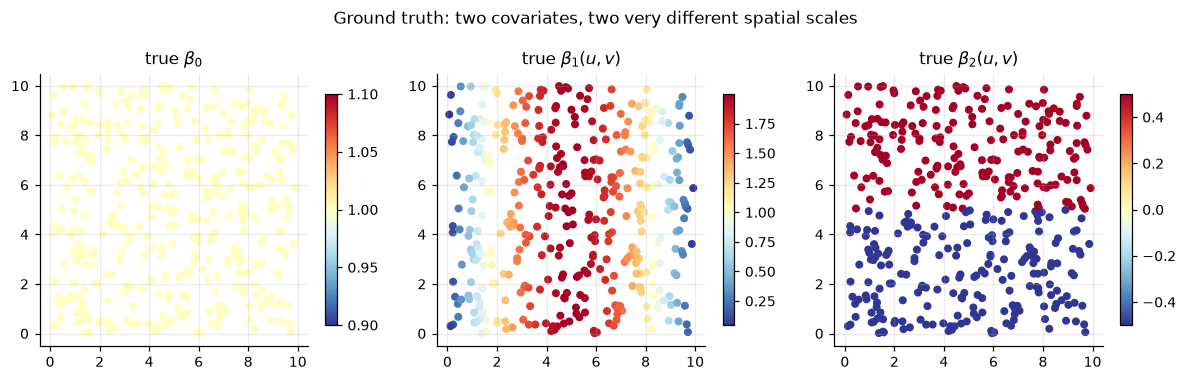

In [4]:
# ---------------------------------------------------------------
# Synthetic study region with genuinely non-stationary coefficients
# ---------------------------------------------------------------
def make_spatial_data(n=400, seed=42, noise=0.6):
    rng = np.random.default_rng(seed)
    u = rng.uniform(0, 10, n)          # x-coordinate
    v = rng.uniform(0, 10, n)          # y-coordinate
    x1 = rng.normal(0, 1, n)
    x2 = rng.normal(0, 1, n)

    # True coefficient SURFACES (this is what GWR must recover)
    b0 = 1.0 + 0.0 * u                       # constant intercept
    b1 = 2.0 * np.sin(np.pi * u / 10)        # smooth E-W gradient  (LARGE scale)
    b2 = 0.5 * (v > 5) - 0.5 * (v <= 5)      # abrupt N-S switch    (SMALL scale)

    y = b0 + b1 * x1 + b2 * x2 + rng.normal(0, noise, n)
    df = pd.DataFrame(dict(u=u, v=v, x1=x1, x2=x2, y=y, b0=b0, b1=b1, b2=b2))
    return df

df = make_spatial_data()
coords = df[["u", "v"]].to_numpy()
X = np.c_[np.ones(len(df)), df[["x1", "x2"]].to_numpy()]   # design matrix with intercept
y = df["y"].to_numpy()
names = ["Intercept", "x1", "x2"]

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
for a, col, t in zip(ax, ["b0", "b1", "b2"],
                     [r"true $\beta_0$", r"true $\beta_1(u,v)$", r"true $\beta_2(u,v)$"]):
    s = a.scatter(df.u, df.v, c=df[col], cmap="RdYlBu_r", s=18)
    a.set_title(t); a.set_aspect("equal"); plt.colorbar(s, ax=a, shrink=.85)
plt.suptitle("Ground truth: two covariates, two very different spatial scales", y=1.04)
plt.tight_layout(); plt.show()

In [6]:
# ---------------------------------------------------------------
# Global OLS: what a stationary model reports
# ---------------------------------------------------------------
beta_ols, *_ = np.linalg.lstsq(X, y, rcond=None)
resid_ols = y - X @ beta_ols
r2_ols = 1 - resid_ols.var() / y.var()

print("Global OLS coefficients")
for nm, b in zip(names, beta_ols):
    print(f"  {nm:<10s} {b:+.3f}")
print(f"  R^2 = {r2_ols:.3f}")
print("\nTrue spatial means  ->  b1: %+.3f   b2: %+.3f"
      % (df.b1.mean(), df.b2.mean()))
print("True spatial ranges ->  b1: [%+.2f, %+.2f]   b2: [%+.2f, %+.2f]"
      % (df.b1.min(), df.b1.max(), df.b2.min(), df.b2.max()))

Global OLS coefficients
  Intercept  +0.924
  x1         +1.206
  x2         -0.015
  R^2 = 0.580

True spatial means  ->  b1: +1.289   b2: -0.007
True spatial ranges ->  b1: [+0.05, +2.00]   b2: [-0.50, +0.50]


**Read that output carefully.** OLS recovers the *spatial average* of $\beta_2$, which is close to zero — so a global model would report "$x_2$ doesn't matter", when in fact $x_2$ has a strong effect everywhere; the effect simply reverses sign across the region. This is the single most compelling argument for local modelling, and it is also the reason GW models are so easy to over-interpret: a wiggly coefficient surface is *evidence-shaped* but not automatically *evidence*.

<a id="2"></a>
# 2. How It Works

The GWR algorithm has five ingredients. We build each one in code.

```
      (1) distance metric  d_ij
                 |
      (2) kernel K(d/b)  ->  weights w_ij
                 |
      (3) bandwidth b chosen by CV / AICc
                 |
      (4) local WLS at every calibration point -> beta(u_i, v_i)
                 |
      (5) inference & diagnostics: local SEs, t-tests, ENP, local R^2, local VIF
```

## 2.1 Distance

The default is Euclidean distance on projected coordinates,

$$d_{ij}=\sqrt{(u_i-u_j)^2+(v_i-v_j)^2}.$$

**Always project first.** Computing Euclidean distance on latitude/longitude degrees distorts space badly away from the equator; use a locally appropriate projected CRS (UTM, Albers, State Plane) or great-circle distance. Alternatives — Minkowski, network, travel-time, spatiotemporal — are covered in Section 4.

## 2.2 Kernels

A kernel $K(\cdot)$ maps distance to weight, decaying in $d$ with $K(0)=1$. The common choices:

$$
\begin{aligned}
\textbf{Gaussian:}\quad & w_{ij} = \exp\!\left(-\tfrac12 (d_{ij}/b)^2\right) && \text{(continuous, never exactly 0)}\\[2pt]
\textbf{Exponential:}\quad & w_{ij} = \exp\!\left(-d_{ij}/b\right) && \text{(heavier near-tail)}\\[2pt]
\textbf{Bi-square:}\quad & w_{ij} = \left[1-(d_{ij}/b)^2\right]^2 \mathbb 1\{d_{ij}<b\} && \text{(compact support)}\\[2pt]
\textbf{Tri-cube:}\quad & w_{ij} = \left[1-(d_{ij}/b)^3\right]^3 \mathbb 1\{d_{ij}<b\} && \text{(compact, flatter centre)}\\[2pt]
\textbf{Box-car:}\quad & w_{ij} = \mathbb 1\{d_{ij}<b\} && \text{(unweighted moving window)}
\end{aligned}
$$

Compact-support kernels (bi-square, tri-cube) are usually preferred: they make each local regression genuinely local, produce sparse $\mathbf W_i$, and are far faster. The *shape* of the kernel matters much less than the bandwidth.

## 2.3 Fixed vs adaptive bandwidth

* **Fixed:** $b$ is a distance (metres). Suits regularly spaced data. Where data are sparse, local samples become tiny and $\mathbf X^{\top}\mathbf W_i\mathbf X$ can be singular.
* **Adaptive:** $b_i$ = distance from $i$ to its $k$-th nearest neighbour, so *every* local regression uses the same effective sample size $k$. This is the safe default for irregular geographies (counties, health districts, survey points) and it is what the code below uses.


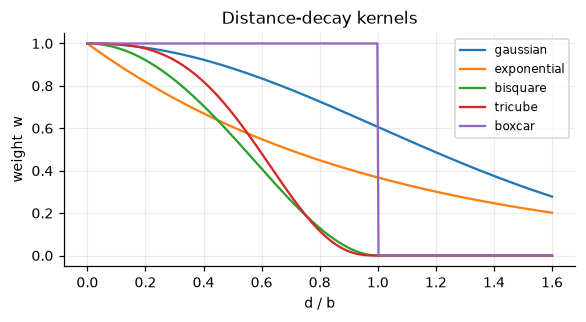

In [7]:
# ---------------------------------------------------------------
# (1) Distances and (2) Kernels
# ---------------------------------------------------------------
def kernel_weights(d, bw, kernel="bisquare", adaptive=True):
    '''Distance vector/matrix -> weights.
    adaptive=True: bw is an integer k (number of nearest neighbours).'''
    d = np.atleast_2d(d)
    if adaptive:
        k = int(np.clip(bw, 2, d.shape[1]))
        # per-row bandwidth = distance to the k-th nearest neighbour
        b = np.partition(d, k - 1, axis=1)[:, k - 1][:, None]
        b = np.where(b <= 0, 1e-12, b)
    else:
        b = float(bw)
    z = d / b
    if kernel == "gaussian":    w = np.exp(-0.5 * z ** 2)
    elif kernel == "exponential": w = np.exp(-z)
    elif kernel == "bisquare":  w = np.where(z < 1, (1 - z ** 2) ** 2, 0.0)
    elif kernel == "tricube":   w = np.where(z < 1, (1 - z ** 3) ** 3, 0.0)
    elif kernel == "boxcar":    w = (z < 1).astype(float)
    else: raise ValueError(kernel)
    return w

# visualise the kernels
zz = np.linspace(0, 1.6, 400)[None, :]
fig, ax = plt.subplots(figsize=(5.4, 3))
for k in ["gaussian", "exponential", "bisquare", "tricube", "boxcar"]:
    ax.plot(zz.ravel(), kernel_weights(zz, 1.0, k, adaptive=False).ravel(), label=k)
ax.set_xlabel("d / b"); ax.set_ylabel("weight  w"); ax.legend(fontsize=8)
ax.set_title("Distance-decay kernels"); plt.tight_layout(); plt.show()

## 2.4 Estimation: the local weighted least squares engine

For each calibration point $i$:

$$
\hat{\boldsymbol\beta}_i = \bigl(\mathbf X^{\top}\mathbf W_i\mathbf X\bigr)^{-1}\mathbf X^{\top}\mathbf W_i\mathbf y
\;=\;\mathbf C_i\,\mathbf y ,
\qquad \mathbf C_i = (\mathbf X^{\top}\mathbf W_i\mathbf X)^{-1}\mathbf X^{\top}\mathbf W_i .
$$

Numerically, never form the inverse. Solve the weighted normal equations by QR on $\sqrt{\mathbf W_i}\mathbf X$, or use `np.linalg.solve` with a small ridge term when the local design is ill-conditioned.

**Effective number of parameters.** Because $\hat{\mathbf y} = \mathbf S\mathbf y$,

$$
\mathrm{ENP} = \operatorname{tr}(\mathbf S),\qquad
\nu_2 = \operatorname{tr}(\mathbf S^{\top}\mathbf S),\qquad
\hat\sigma^2 = \frac{\text{RSS}}{n - 2\operatorname{tr}(\mathbf S)+\operatorname{tr}(\mathbf S^{\top}\mathbf S)} .
$$

ENP replaces "number of coefficients" in every model-selection formula. A GWR with 3 covariates might use an ENP of 40 — that is the price of locality, and it is exactly what the information criteria charge for.

**Local standard errors and $t$-statistics.**

$$
\operatorname{Var}\bigl(\hat{\boldsymbol\beta}_i\bigr) = \hat\sigma^{2}\,\mathbf C_i\mathbf C_i^{\top},
\qquad
\mathrm{SE}(\hat\beta_{ik}) = \hat\sigma\sqrt{\bigl[\mathbf C_i\mathbf C_i^{\top}\bigr]_{kk}},
\qquad
t_{ik} = \frac{\hat\beta_{ik}}{\mathrm{SE}(\hat\beta_{ik})} .
$$

**Local goodness of fit.**

$$
R^2_i \;=\; 1 - \frac{\sum_j w_{ij}(y_j-\hat y_j)^2}{\sum_j w_{ij}(y_j-\bar y_i^{w})^2},
\qquad \bar y^w_i=\frac{\sum_j w_{ij}y_j}{\sum_j w_{ij}} .
$$


In [8]:
# ---------------------------------------------------------------
# (4) The GWR engine
# ---------------------------------------------------------------
class GWR:
    '''Scratch GWR for pedagogy — use spatialstats.gwmodel.linear.GWR in production.

    Basic Geographically Weighted Regression (Brunsdon et al., 1996).'''

    def __init__(self, bw, kernel="bisquare", adaptive=True, ridge=1e-10):
        self.bw, self.kernel, self.adaptive, self.ridge = bw, kernel, adaptive, ridge

    def fit(self, coords, X, y, calib=None):
        self.coords, self.X, self.y = coords, X, y
        calib = coords if calib is None else calib
        n, p = X.shape
        D = cdist(calib, coords)
        W = kernel_weights(D, self.bw, self.kernel, self.adaptive)

        beta = np.empty((len(calib), p))
        Smat = np.empty((len(calib), n))       # hat matrix rows
        CCt  = np.empty((len(calib), p))       # diag of C_i C_i'
        localR2 = np.empty(len(calib))

        for i in range(len(calib)):
            w = W[i]
            Xw = X * w[:, None]
            A  = X.T @ Xw + self.ridge * np.eye(p)
            C  = np.linalg.solve(A, Xw.T)      # p x n  ->  C_i
            beta[i] = C @ y
            Smat[i] = X[i] @ C if calib is coords else 0.0
            CCt[i]  = np.einsum("ij,ij->i", C, C)

        self.beta = beta
        if calib is coords:
            self.S      = Smat
            self.yhat   = np.einsum("ij,ij->i", X, beta)
            self.resid  = y - self.yhat
            self.RSS    = float(self.resid @ self.resid)
            self.tr_S   = float(np.trace(Smat))
            self.tr_StS = float(np.sum(Smat * Smat))
            self.enp    = self.tr_S
            dof         = n - 2 * self.tr_S + self.tr_StS
            self.sigma2 = self.RSS / dof
            self.se     = np.sqrt(self.sigma2 * CCt)
            self.tvals  = beta / self.se
            self.R2     = 1 - self.RSS / float(((y - y.mean()) ** 2).sum())
            self.adjR2  = 1 - (1 - self.R2) * (n - 1) / (n - self.enp - 1)
            self.aicc   = (2 * n * np.log(np.sqrt(self.RSS / n)) + n * np.log(2 * np.pi)
                           + n * (n + self.tr_S) / (n - 2 - self.tr_S))
            # local R^2
            for i in range(n):
                w = W[i]; sw = w.sum()
                ybar = (w @ y) / sw
                localR2[i] = 1 - (w @ (self.resid ** 2)) / (w @ ((y - ybar) ** 2))
            self.localR2 = localR2
        return self

    def predict(self, coords_new, X_new):
        b = GWR(self.bw, self.kernel, self.adaptive).fit(
            self.coords, self.X, self.y, calib=coords_new).beta
        return np.einsum("ij,ij->i", X_new, b)


m = GWR(bw=60).fit(coords, X, y)
print(f"ENP = {m.enp:6.2f}   sigma^2 = {m.sigma2:.3f}   R2 = {m.R2:.3f}   AICc = {m.aicc:.1f}")

ENP =  52.64   sigma^2 = 0.451   R2 = 0.845   AICc = 863.1


### PySpatialStats equivalent

The scratch `GWR` class above mirrors the mathematics in `spatialstats.gwmodel.linear.GWR`. The package version adds parallel fitting (`n_jobs`), automatic bandwidth selection (`bandwidth='auto'`), BH-corrected $p$-values, and a `summary()` table — without changing the underlying WLS estimator.


In [9]:
# Same synthetic data, PySpatialStats implementation
X_noint = df[["x1", "x2"]].to_numpy()   # intercept added internally by PyGWR

py_gwr = PyGWR(bandwidth=60, fixed=False, kernel="bisquare")
py_gwr.fit(X_noint, y, coords)

print(py_gwr.summary())
print(f"\nScratch ENP={m.enp:.1f}  AICc={m.aicc:.1f}  |  "
      f"PyGWR ENP={py_gwr.effective_df_:.1f}  AICc={py_gwr.aicc_:.1f}")


Geographically Weighted Regression (GWR) Summary
  Observations            : 400
  Predictors (incl. int.) : 3
  Bandwidth               : 60.0000
  Kernel                  : bisquare
  Fixed                   : False
  AICc                    : 73.6311
  Effective DF            : 51.7928
  Global R²               : 0.8443

  Local coefficient summary (min / median / max):
    Intercept      : 0.7212 / 0.8884 / 1.0637
    X1             : 0.3580 / 1.3084 / 2.0328
    X2             : -0.7031 / -0.0509 / 0.7190

Scratch ENP=52.6  AICc=863.1  |  PyGWR ENP=51.8  AICc=73.6


## 2.5 Bandwidth selection

The bandwidth is the *only* tuning parameter that materially changes conclusions, so it is chosen by an explicit criterion rather than by eye.

**Leave-one-out cross-validation** (excludes $i$ from its own regression by setting $w_{ii}=0$):

$$
\mathrm{CV}(b) = \sum_{i=1}^{n}\bigl[y_i-\hat y_{\ne i}(b)\bigr]^2 .
$$

**Corrected Akaike information criterion** (Hurvich et al., 1998) — the standard choice, because it penalises the effective complexity:

$$
\boxed{\;
\mathrm{AICc}(b) = 2n\ln\hat\sigma + n\ln(2\pi) + n\left[\frac{n+\operatorname{tr}(\mathbf S)}{n-2-\operatorname{tr}(\mathbf S)}\right]
\;}
$$

Search over $b$ with a golden-section routine (the criterion is usually unimodal in $b$). Differences in AICc of less than ~3 are not meaningful — prefer the larger (smoother) bandwidth in that range, on parsimony grounds.


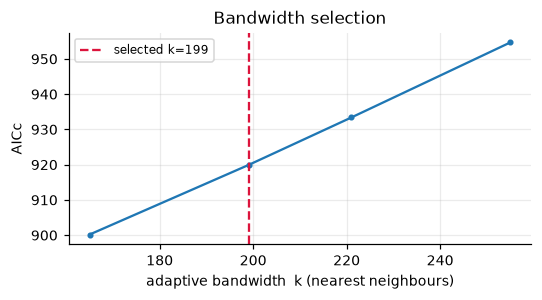

optimal k = 199 | ENP = 15.2 | R2 = 0.776 | adjR2 = 0.767 | AICc = 919.9


In [10]:
# ---------------------------------------------------------------
# (3) Bandwidth search by AICc (golden section over adaptive k)
# ---------------------------------------------------------------
def golden_bw(coords, X, y, lo=None, hi=None, kernel="bisquare", tol=2, verbose=True):
    n = len(y); p = X.shape[1]
    lo = lo or max(p + 5, 20); hi = hi or n
    phi = (np.sqrt(5) - 1) / 2
    cache = {}
    def score(k):
        k = int(round(k))
        if k not in cache:
            cache[k] = GWR(bw=k, kernel=kernel).fit(coords, X, y).aicc
        return cache[k]
    a, b = lo, hi
    c, d = b - phi * (b - a), a + phi * (b - a)
    while abs(b - a) > tol:
        if score(c) < score(d): b, d, c = d, c, b - phi * (b - a)
        else:                   a, c, d = c, d, a + phi * (b - a)
    best = int(round((a + b) / 2))
    if verbose:
        ks = sorted(cache); plt.figure(figsize=(5, 2.8))
        plt.plot(ks, [cache[k] for k in ks], "o-", ms=3)
        plt.axvline(best, color="crimson", ls="--", label=f"selected k={best}")
        plt.xlabel("adaptive bandwidth  k (nearest neighbours)"); plt.ylabel("AICc")
        plt.legend(fontsize=8); plt.title("Bandwidth selection"); plt.tight_layout(); plt.show()
    return best

bw_opt = golden_bw(coords, X, y)
gwr = GWR(bw=bw_opt).fit(coords, X, y)
print(f"optimal k = {bw_opt} | ENP = {gwr.enp:.1f} | R2 = {gwr.R2:.3f} "
      f"| adjR2 = {gwr.adjR2:.3f} | AICc = {gwr.aicc:.1f}")

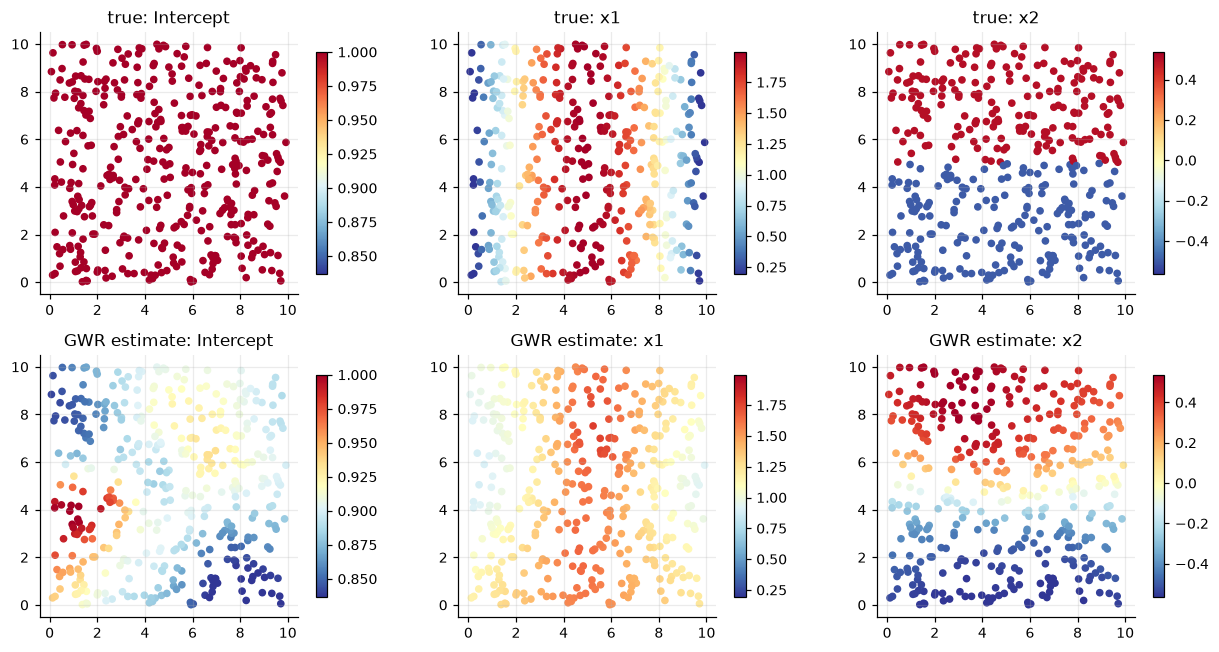

Correlation between true and estimated surfaces:
  Intercept  true surface is constant (estimated s.d. = 0.039)
  x1         r =  0.890
  x2         r =  0.923


In [11]:
# ---------------------------------------------------------------
# Recovered coefficient surfaces vs truth
# ---------------------------------------------------------------
fig, ax = plt.subplots(2, 3, figsize=(11.5, 6))
truth = df[["b0", "b1", "b2"]].to_numpy()
for k in range(3):
    lim = np.nanpercentile(np.r_[truth[:, k], gwr.beta[:, k]], [2, 98])
    for r, (vals, lab) in enumerate([(truth[:, k], "true"), (gwr.beta[:, k], "GWR estimate")]):
        s = ax[r, k].scatter(df.u, df.v, c=vals, cmap="RdYlBu_r", s=16,
                             vmin=lim[0], vmax=lim[1])
        ax[r, k].set_title(f"{lab}: {names[k]}"); ax[r, k].set_aspect("equal")
        plt.colorbar(s, ax=ax[r, k], shrink=.85)
plt.tight_layout(); plt.show()

print("Correlation between true and estimated surfaces:")
for k in range(3):
    if truth[:, k].std() < 1e-9:
        print(f"  {names[k]:<10s} true surface is constant "
              f"(estimated s.d. = {gwr.beta[:, k].std():.3f})")
    else:
        print(f"  {names[k]:<10s} r = {np.corrcoef(truth[:, k], gwr.beta[:, k])[0,1]: .3f}")

Note the asymmetry in the result above: the **smooth, large-scale** surface $\beta_1$ is recovered well, while the **abrupt, small-scale** surface $\beta_2$ is smeared across the discontinuity. A single bandwidth must compromise between the two processes — precisely the deficiency that **MGWR** (Section 4.2) fixes.

## 2.6 Inference and the multiple-comparison problem

Each of the $n$ local $t$-tests uses the same data, so the tests are heavily dependent and running $n\times p$ of them at $\alpha=0.05$ guarantees spurious "significant" pockets. Da Silva & Fotheringham (2016) give an adjusted level based on the effective number of parameters attributable to covariate $k$:

$$
\xi_k = \frac{\alpha}{\mathrm{ENP}_k / p},
\qquad \mathrm{ENP}_k = \operatorname{tr}(\mathbf S_k),
$$

which for typical GWR fits lands near $\alpha^{*}\approx 0.01$–$0.02$ rather than $0.05$. Always report which correction you used.

**Testing for non-stationarity itself.** Before interpreting a surface, test whether it varies more than sampling noise would produce:

* **Monte-Carlo / permutation test** — randomly permute the coordinates (breaking any spatial structure while preserving the marginal distributions), refit GWR, and compare the observed variance of $\hat\beta_k$ to its permutation distribution.
* **ANOVA-style $F$ test** comparing OLS and GWR residual sums of squares with ENP-based degrees of freedom (Brunsdon et al., 1999; Leung et al., 2000).


In [12]:
# ---------------------------------------------------------------
# Monte-Carlo test for spatial non-stationarity of each coefficient
# ---------------------------------------------------------------
def mc_nonstationarity(coords, X, y, bw, n_perm=99, seed=0):
    rng = np.random.default_rng(seed)
    obs = GWR(bw=bw).fit(coords, X, y).beta.var(axis=0)
    null = np.empty((n_perm, X.shape[1]))
    for r in range(n_perm):
        idx = rng.permutation(len(y))
        null[r] = GWR(bw=bw).fit(coords[idx], X, y).beta.var(axis=0)
    pvals = (np.sum(null >= obs, axis=0) + 1) / (n_perm + 1)
    return obs, pvals

obs_var, pvals = mc_nonstationarity(coords, X, y, bw_opt, n_perm=49)
print(f"{'coefficient':<12}{'Var(beta)':>12}{'p (MC)':>10}   verdict")
for nm, v, p in zip(names, obs_var, pvals):
    print(f"{nm:<12}{v:12.4f}{p:10.3f}   {'non-stationary' if p < .05 else 'no evidence'}")

coefficient    Var(beta)    p (MC)   verdict
Intercept         0.0015     0.940   no evidence
x1                0.0537     0.020   non-stationary
x2                0.1749     0.020   non-stationary


In [ ]:
# ---------------------------------------------------------------
# Local inference maps with the Da Silva-Fotheringham correction
# ---------------------------------------------------------------
alpha = 0.05
# Da Silva & Fotheringham (2016): xi = alpha / (ENP_k / p), approximating ENP_k = ENP / p
alpha_adj = alpha / (gwr.enp / X.shape[1] / X.shape[1])
tcrit = stats.t.ppf(1 - alpha_adj / 2, df=len(y) - gwr.enp)
print(f"nominal alpha = {alpha}  ->  adjusted alpha = {alpha_adj:.4f}, |t*| = {tcrit:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
for k in range(3):
    sig = np.abs(gwr.tvals[:, k]) > tcrit
    ax[k].scatter(df.u[~sig], df.v[~sig], c="lightgrey", s=12, label="n.s.")
    s = ax[k].scatter(df.u[sig], df.v[sig], c=gwr.beta[sig, k], cmap="RdYlBu_r", s=18)
    ax[k].set_title(f"{names[k]}  ({sig.mean()*100:.0f}% significant)")
    ax[k].set_aspect("equal"); plt.colorbar(s, ax=ax[k], shrink=.85)
plt.suptitle("Local coefficients, non-significant locations greyed out", y=1.05)
plt.tight_layout(); plt.show()

## 2.7 Diagnostics you must run

| Diagnostic | Formula / method | What it catches |
|---|---|---|
| **Local condition number** | $\kappa_i=\sqrt{\lambda_{\max}/\lambda_{\min}}$ of the locally weighted, scaled $\mathbf X^{\top}\mathbf W_i\mathbf X$ | local collinearity; $\kappa_i>30$ is a red flag |
| **Local VIF** | $\mathrm{VIF}_{ik}=1/(1-R^2_{ik})$ from local auxiliary regressions | which covariate pair is collinear, and where |
| **Local correlation** | GW correlation of covariate pairs (see GWSS) | the spatial footprint of the collinearity |
| **Residual autocorrelation** | Moran's $I$ on GWR residuals | remaining unmodelled spatial structure |
| **ENP / bandwidth stability** | refit across a grid of $b$ | conclusions that hinge on one bandwidth |
| **Sensitivity to kernel** | Gaussian vs bi-square | over-reading of kernel artefacts |

**Local collinearity is the single most common source of bogus GWR maps.** Wheeler & Tiefelsdorf (2005) showed that even when covariates are globally uncorrelated, they can be strongly correlated *within* a bandwidth, producing dramatic, spatially smooth, and entirely artefactual coefficient patterns — often two surfaces that mirror each other. If your GWR produces a strong positive surface for one covariate and its exact negative twin for another, suspect collinearity before you suspect a mechanism.


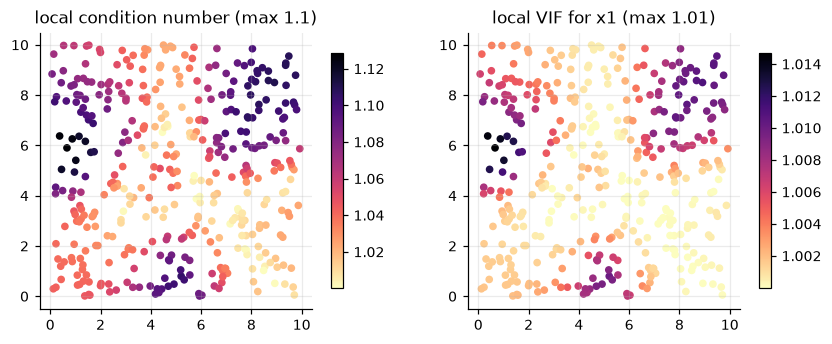

Rule of thumb: condition number > 30 or local VIF > 10 => do not interpret the surface.


In [13]:
# ---------------------------------------------------------------
# Local collinearity diagnostics
# ---------------------------------------------------------------
def local_collinearity(coords, X, bw, kernel="bisquare"):
    n, p = X.shape
    D = cdist(coords, coords)
    W = kernel_weights(D, bw, kernel, adaptive=True)
    cond = np.empty(n); vif = np.empty((n, p - 1))
    for i in range(n):
        w = W[i]; sw = w.sum()
        Xs = X.copy()
        mu = (w @ X[:, 1:]) / sw
        sd = np.sqrt((w @ (X[:, 1:] - mu) ** 2) / sw)
        Xs[:, 1:] = (X[:, 1:] - mu) / np.where(sd == 0, 1, sd)
        A = (Xs * w[:, None]).T @ Xs
        ev = np.linalg.eigvalsh(A)
        cond[i] = np.sqrt(ev.max() / max(ev.min(), 1e-12))
        for k in range(1, p):                       # local VIF for covariate k
            others = [c for c in range(p) if c not in (k,)]
            Z = Xs[:, others]; t = Xs[:, k]
            bb = np.linalg.lstsq(Z * np.sqrt(w)[:, None], t * np.sqrt(w), rcond=None)[0]
            r = t - Z @ bb
            ss_t = (w * (t - (w @ t) / sw) ** 2).sum()
            vif[i, k - 1] = 1 / max(1 - (1 - (w * r ** 2).sum() / ss_t), 1e-6)
    return cond, vif

cond, vif = local_collinearity(coords, X, bw_opt)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.1))
s = ax[0].scatter(df.u, df.v, c=cond, cmap="magma_r", s=16); ax[0].set_aspect("equal")
ax[0].set_title(f"local condition number (max {cond.max():.1f})"); plt.colorbar(s, ax=ax[0], shrink=.85)
s = ax[1].scatter(df.u, df.v, c=vif[:, 0], cmap="magma_r", s=16); ax[1].set_aspect("equal")
ax[1].set_title(f"local VIF for x1 (max {vif[:,0].max():.2f})"); plt.colorbar(s, ax=ax[1], shrink=.85)
plt.tight_layout(); plt.show()
print("Rule of thumb: condition number > 30 or local VIF > 10 => do not interpret the surface.")

<a id="3"></a>
# 3. Applications and Limitations

## 3.1 Where GW models earn their keep

**Public health & epidemiology.** Spatially varying exposure–outcome relationships: air pollution and respiratory mortality, socioeconomic deprivation and cancer incidence, food-environment measures and obesity, healthcare-access measures and utilisation. GW models turn "does deprivation matter?" into "*where* does deprivation matter most, and how much?" — the form of the question that resource allocation actually needs.

**Environmental & earth science.** Soil property mapping, land-surface temperature vs. impervious cover, species–environment relationships, downscaling of remotely sensed products, spatial calibration of satellite retrievals.

**Agriculture.** Yield response to nitrogen, weather, and management across agro-ecological zones; site-specific management zone delineation; GHG-emission drivers that differ by soil and hydrology.

**Urban & real estate.** Hedonic house-price models (the canonical application), where the implicit price of a bedroom, a garage, or proximity to a park is obviously not constant across a metropolitan area.

**Crime, transport, economics.** Local elasticities of demand, spatially varying deterrence effects, accessibility studies.

**Two distinct uses.** (i) *Exploratory* — surface a pattern for hypothesis generation; (ii) *predictive* — a flexible spatial-interaction learner. GW models are excellent at the first and often competitive at the second, but the inferential apparatus is much weaker than the maps suggest.

## 3.2 Limitations — read before publishing a map

| Limitation | Why it bites | Mitigation |
|---|---|---|
| **Local collinearity** | correlated covariates inside a bandwidth produce smooth, mirrored, meaningless surfaces | local CN/VIF, GW-ridge, GW-lasso, drop or combine covariates, use MGWR |
| **Bandwidth sensitivity** | conclusions can flip with $b$ | report AICc profile; show maps at 2–3 bandwidths |
| **Multiple testing** | $n\times p$ dependent $t$-tests | Da Silva–Fotheringham correction; Monte-Carlo tests |
| **Single scale (basic GWR)** | one $b$ for processes operating at different scales | **MGWR** |
| **Edge effects** | boundary points have asymmetric neighbourhoods → inflated variance | buffer the study area; report edge flags; adaptive bandwidth |
| **MAUP & support** | results depend on zoning and aggregation level | sensitivity analysis across scales; use point support where possible |
| **Not a causal method** | a varying coefficient is still a conditional association | combine with a design (DiD, IV, RD); pre-register the hypothesis |
| **Overfitting / extrapolation** | high ENP, wiggly surfaces; extrapolation beyond the data hull is unreliable | cross-validate spatially (block/leave-region-out), not randomly |
| **Computation** | naive implementation is $O(n^2p^2 + n p^3)$; the $n\times n$ distance matrix is $O(n^2)$ memory | compact kernels, k-d trees, parallelisation, GPU, scalable-GWR approximations |
| **Confusion with spatial autocorrelation models** | GWR addresses *heterogeneity*, not *dependence* | consider SAR/SEM/CAR or spatially-lagged GWR if residual $I$ remains significant |
| **Interpretability of local $p$-values** | classical inference assumes independent samples | treat maps as exploratory unless permutation-validated |

**One more caution.** Because GWR borrows strength from neighbours, its coefficient surfaces are *smoothed by construction*. Smoothness in a map is not evidence of a smooth underlying process; it can be an artefact of the kernel. This is why the permutation test in §2.6 is not optional.


<a id="4"></a>
# 4. The PySpatialStats Zoo

The table below is the **PySpatialStats model catalogue**. Each row is a class you can import directly; subsections that follow explain the theory and show a minimal NumPy implementation for transparency.

| Module | Model | Algorithm | Core generalisation |
|---|---|---|---|
| `linear` | `GWR` | Geographically Weighted Regression | baseline local WLS |
| `linear` | `MGWR` | Multiscale GWR | one bandwidth **per covariate** |
| `linear` | `GWGLM` | GW Generalised Linear Models | local **likelihood** (Poisson, binomial) |
| `linear` | `GWSS` | GW Summary Statistics | no covariates — local moments & correlations |
| `linear` | `MixedGWR` | Semiparametric Mixed GWR | some coefficients **global**, some local |
| `spatiotemporal` | `GTWR` | Geographically & Temporally WR | space **and time** in the distance metric |
| `ensemble` | `GWRandomForest` | GW Random Forest | local **non-linear** learner |
| `ensemble` | `GWXGBoost` | GW XGBoost | local gradient boosting |
| `ensemble` | `GWLightGBM` | GW LightGBM | local gradient boosting (histogram/leaf-wise) |
| `deep` | `GNNWR` | Neural Network Weighted Regression | **learned** weighting function |
| `deep` | `GTNNWR` | Spatiotemporal NN Weighted Regression | learned spatiotemporal proximity |
| `multivariate` | `GWPCA` | GW Principal Component Analysis | local covariance eigen-structure |
| `network` | `NetworkGWR` | Network-distance GWR | shortest-path / travel-time metric |

---

## 4.1 `linear.GWR` — Geographically Weighted Regression

**Model.**

$$
y_i = \beta_0(u_i,v_i)+\sum_{k=1}^{p}\beta_k(u_i,v_i)x_{ik}+\varepsilon_i,
\qquad
\hat{\boldsymbol\beta}(u_i,v_i)=(\mathbf X^{\top}\mathbf W_i\mathbf X)^{-1}\mathbf X^{\top}\mathbf W_i\mathbf y .
$$

**Estimator:** $n$ independent weighted least squares problems; one bandwidth shared by all covariates. **Complexity:** $O(n^2p^2+np^3)$ time, $O(n^2)$ memory for the dense distance matrix.

**Outputs:** coefficient surfaces, local SEs and $t$-values, local $R^2$, ENP, AICc, residuals.

**Use it when** you want a first, interpretable, well-understood picture of spatial non-stationarity in a linear relationship, and you are willing to assume all processes operate at roughly the same spatial scale.

**Don't use it when** covariates plausibly act at very different scales (→ MGWR), the response is a count or a proportion (→ GWGLM), or the relationship is strongly non-linear (→ GW ensembles / GNNWR).

*Scratch implementation: `GWR` class in Section 2.4. Production API:*

```python
from spatialstats.gwmodel.linear import GWR
model = GWR(bandwidth='auto', fixed=False, kernel='bisquare')
model.fit(X, y, coords)   # X without intercept; added internally
print(model.summary())
```

Below we summarise the fitted scratch model and compare with `PyGWR`.


In [ ]:
# GWR summary table
summary = pd.DataFrame({
    "coefficient": names,
    "min":  gwr.beta.min(axis=0),
    "q25":  np.percentile(gwr.beta, 25, axis=0),
    "median": np.median(gwr.beta, axis=0),
    "q75":  np.percentile(gwr.beta, 75, axis=0),
    "max":  gwr.beta.max(axis=0),
    "OLS":  beta_ols,
}).round(3)
print("GWR local coefficient distribution vs global OLS\n")
print(summary.to_string(index=False))
print(f"\nDiagnostics: n={len(y)}  ENP={gwr.enp:.1f}  AICc={gwr.aicc:.1f}  "
      f"R2={gwr.R2:.3f}  adjR2={gwr.adjR2:.3f}")

In [ ]:
# PySpatialStats GWR on the same synthetic data (for side-by-side comparison)
py_gwr2 = PyGWR(bandwidth=bw_opt, fixed=False, kernel="bisquare")
py_gwr2.fit(X_noint, y, coords)
print(py_gwr2.summary())

fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
for a, b, t in zip(ax, [gwr.beta[:, 1], py_gwr2.coef_[:, 1]],
                   ["Scratch GWR β₁", "PyGWR β₁"]):
    s = a.scatter(df.u, df.v, c=b, cmap="RdYlBu_r", s=16)
    a.set_title(t); a.set_aspect("equal"); plt.colorbar(s, ax=a, shrink=.85)
plt.suptitle("Coefficient surfaces: scratch vs PySpatialStats", y=1.02)
plt.tight_layout(); plt.show()


## 4.2 `linear.MGWR` — Multiscale GWR

Basic GWR forces every relationship through one spatial lens. **MGWR** (Fotheringham, Yang & Kang, 2017) gives each covariate its **own** bandwidth $b_k$, so the model reports not only *where* a relationship changes but *at what spatial scale* it operates:

$$
y_i=\beta_{b_0}(u_i,v_i)+\sum_{k=1}^{p}\beta_{b_k}(u_i,v_i)\,x_{ik}+\varepsilon_i .
$$

This is a **generalised additive model** in disguise: write $f_k = \beta_{b_k}\odot \mathbf x_k$ so that $\mathbf y=\sum_k \mathbf f_k+\boldsymbol\varepsilon$, and estimate by **back-fitting**:

$$
\textbf{repeat until convergence:}\qquad
\begin{cases}
\text{partial residual: } & \boldsymbol\epsilon_{(k)} = \mathbf y - \sum_{l\ne k}\hat{\mathbf f}_l \\[4pt]
\text{calibrate: } & b_k \leftarrow \arg\min_b \mathrm{AICc}\bigl(\text{GWR}(\boldsymbol\epsilon_{(k)}\sim \mathbf x_k;\,b)\bigr) \\[4pt]
\text{update: } & \hat{\mathbf f}_k = \hat\beta_{b_k}\odot\mathbf x_k
\end{cases}
$$

Convergence is monitored by the **score of change** in RSS:
$$\mathrm{SOC\text{-}RSS}=\frac{|\mathrm{RSS}^{(t)}-\mathrm{RSS}^{(t-1)}|}{\mathrm{RSS}^{(t)}}<10^{-5}.$$

**Interpretation.** A near-$n$ bandwidth means that covariate is effectively **global/stationary**; a small bandwidth means a highly local process. MGWR typically yields *smoother, more stable, less collinear* surfaces than GWR and lower AICc. Inference uses the additive hat matrix $\mathbf R_k$ for each term (Yu et al., 2020).

**Cost.** Each back-fitting iteration runs $p$ GWR fits *and* $p$ bandwidth searches — an order of magnitude more expensive than GWR.


In [ ]:
# ---------------------------------------------------------------
# MGWR by back-fitting (one bandwidth per covariate)
# ---------------------------------------------------------------
def mgwr(coords, X, y, kernel="bisquare", max_iter=30, tol=1e-5, verbose=True):
    n, p = X.shape
    D = cdist(coords, coords)

    def gwr_1d(xk, target, bw):                      # univariate local regression
        W = kernel_weights(D, bw, kernel, adaptive=True)
        num = (W * (xk[None, :] * target[None, :])).sum(1)
        den = (W * (xk[None, :] ** 2)).sum(1)
        return num / np.where(den == 0, 1e-12, den)

    def aicc_1d(xk, target, bw):
        W = kernel_weights(D, bw, kernel, adaptive=True)
        b = gwr_1d(xk, target, bw)
        fit = b * xk
        rss = float(((target - fit) ** 2).sum())
        trS = float(np.sum([W[i, i] * xk[i] ** 2 / max((W[i] * xk ** 2).sum(), 1e-12)
                            for i in range(n)]))
        return 2*n*np.log(np.sqrt(rss/n)) + n*np.log(2*np.pi) + n*(n+trS)/(n-2-trS)

    def search_bw(xk, target):
        grid = np.unique(np.linspace(max(20, p+5), n, 14).astype(int))
        return int(grid[np.argmin([aicc_1d(xk, target, k) for k in grid])])

    # initialise from a standard GWR fit
    bw0 = golden_bw(coords, X, y, verbose=False)
    f = GWR(bw=bw0).fit(coords, X, y).beta * X
    bws = [bw0] * p
    rss_old = np.inf
    for it in range(max_iter):
        for k in range(p):
            eps_k = y - np.delete(f, k, axis=1).sum(1)      # partial residual
            bws[k] = search_bw(X[:, k], eps_k)
            f[:, k] = gwr_1d(X[:, k], eps_k, bws[k]) * X[:, k]
        rss = float(((y - f.sum(1)) ** 2).sum())
        soc = abs(rss_old - rss) / max(rss, 1e-12)
        if verbose: print(f"  iter {it+1:2d}  RSS={rss:8.2f}  SOC={soc:.2e}  bw={bws}")
        if soc < tol: break
        rss_old = rss
    beta = f / np.where(X == 0, np.nan, X)
    return dict(beta=beta, bws=bws, fitted=f.sum(1), rss=rss)

print("MGWR back-fitting:")
res_m = mgwr(coords, X, y)
print("\nSelected bandwidths (adaptive k, larger = more global):")
for nm, b in zip(names, res_m["bws"]):
    scale = "essentially GLOBAL" if b > 0.8*len(y) else ("regional" if b > 0.35*len(y) else "LOCAL")
    print(f"  {nm:<10s} k = {b:4d}   -> {scale}")

In [ ]:
# Compare GWR vs MGWR against the truth for the small-scale covariate x2
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
lim = (-0.9, 0.9)
for a, vals, t in zip(ax,
                      [df.b2.to_numpy(), gwr.beta[:, 2], res_m["beta"][:, 2]],
                      ["TRUE beta2", f"GWR (single bw={bw_opt})",
                       f"MGWR (bw={res_m['bws'][2]})"]):
    s = a.scatter(df.u, df.v, c=vals, cmap="RdYlBu_r", s=16, vmin=lim[0], vmax=lim[1])
    a.set_title(t); a.set_aspect("equal"); plt.colorbar(s, ax=a, shrink=.85)
plt.tight_layout(); plt.show()

for lab, b in [("GWR ", gwr.beta), ("MGWR", res_m["beta"])]:
    print(f"{lab} corr with truth:  b1 {np.corrcoef(df.b1, b[:,1])[0,1]:+.3f}   "
          f"b2 {np.corrcoef(df.b2, b[:,2])[0,1]:+.3f}")

## 4.3 `linear.GWGLM` — Geographically Weighted Generalised Linear Models

When $y$ is a **count** (disease cases, crashes, crimes), a **proportion/binary** outcome, or otherwise non-Gaussian, squared-error loss is the wrong objective. GWGLM replaces the local WLS criterion with a **local log-likelihood**:

$$
\hat{\boldsymbol\beta}(u_i,v_i)=\arg\max_{\boldsymbol\beta}\;\sum_{j=1}^{n} w_{ij}\,\ell\bigl(y_j;\,g^{-1}(\mathbf x_j^{\top}\boldsymbol\beta)\bigr),
$$

with link $g$. Estimation is **geographically weighted IRLS**: at iteration $t$, form the working response and GLM weights

$$
z_j^{(t)} = \eta_j^{(t)}+\frac{y_j-\mu_j^{(t)}}{\partial\mu/\partial\eta},
\qquad
a_j^{(t)} = \frac{(\partial\mu/\partial\eta)^2}{V(\mu_j^{(t)})},
$$

and solve

$$
\boxed{\;
\hat{\boldsymbol\beta}_i^{(t+1)}=\bigl(\mathbf X^{\top}\mathbf W_i\mathbf A^{(t)}\mathbf X\bigr)^{-1}\mathbf X^{\top}\mathbf W_i\mathbf A^{(t)}\mathbf z^{(t)} ,
\;}
$$

i.e. the geographic weights $\mathbf W_i$ and the GLM working weights $\mathbf A$ simply multiply.

Common cases:

| Family | Link | $\mu$ | Variance $V(\mu)$ | Typical use |
|---|---|---|---|---|
| Poisson | $\log$ | $e^{\eta}$ | $\mu$ | disease counts with offset $\log(\text{pop})$ |
| Binomial | logit | $1/(1+e^{-\eta})$ | $\mu(1-\mu)$ | prevalence, presence/absence |
| Gaussian | identity | $\eta$ | $1$ | reduces to GWR |

Model fit uses **local deviance** and a deviance-based AICc; bandwidth is selected by minimising that AICc or by CV deviance. Note two practical hazards: (i) **local separation** in logistic GWGLM when a small neighbourhood has all-0 or all-1 outcomes — use a larger adaptive bandwidth or a Firth/ridge penalty; (ii) **overdispersion** in Poisson models — check the local deviance/df ratio and consider a GW negative-binomial or quasi-Poisson scale.


In [ ]:
# ---------------------------------------------------------------
# GW Poisson regression by geographically weighted IRLS
# ---------------------------------------------------------------
def gwglm_poisson(coords, X, y, bw, offset=None, kernel="bisquare", tol=1e-6, max_iter=50):
    n, p = X.shape
    off = np.zeros(n) if offset is None else np.log(offset)
    D = cdist(coords, coords)
    W = kernel_weights(D, bw, kernel, adaptive=True)
    beta = np.tile(np.linalg.lstsq(X, np.log(np.maximum(y, .5)) - off, rcond=None)[0], (n, 1))
    for it in range(max_iter):
        eta = np.einsum("ij,ij->i", X, beta) + off
        mu  = np.exp(np.clip(eta, -30, 30))
        z   = eta - off + (y - mu) / np.maximum(mu, 1e-8)      # working response
        a   = mu                                               # Poisson IRLS weight
        new = np.empty_like(beta)
        for i in range(n):
            ww = W[i] * a
            A = X.T @ (X * ww[:, None]) + 1e-8 * np.eye(p)
            new[i] = np.linalg.solve(A, X.T @ (ww * z))
        delta = np.abs(new - beta).max(); beta = new
        if delta < tol: break
    eta = np.einsum("ij,ij->i", X, beta) + off
    mu = np.exp(np.clip(eta, -30, 30))
    dev = 2 * np.sum(np.where(y > 0, y * np.log(np.maximum(y, 1e-9) / mu), 0) - (y - mu))
    return dict(beta=beta, mu=mu, deviance=dev, iters=it + 1)

# synthetic count data: spatially varying log-relative-risk
rng = np.random.default_rng(7)
pop  = rng.integers(500, 5000, len(df))
lrr  = -6.0 + 1.2 * np.sin(np.pi * df.u.values / 10) * df.x1.values
counts = rng.poisson(pop * np.exp(lrr))

Xp = np.c_[np.ones(len(df)), df.x1.values]
gp = gwglm_poisson(coords, Xp, counts, bw=80, offset=pop)
print(f"GW-Poisson converged in {gp['iters']} IRLS iterations | deviance = {gp['deviance']:.1f}")

fig, ax = plt.subplots(1, 2, figsize=(8, 3.1))
s = ax[0].scatter(df.u, df.v, c=1.2*np.sin(np.pi*df.u/10), cmap="RdYlBu_r", s=16)
ax[0].set_title("true log-RR slope for x1"); plt.colorbar(s, ax=ax[0], shrink=.85)
s = ax[1].scatter(df.u, df.v, c=gp["beta"][:, 1], cmap="RdYlBu_r", s=16)
ax[1].set_title("GWGLM (Poisson) estimate"); plt.colorbar(s, ax=ax[1], shrink=.85)
for a in ax: a.set_aspect("equal")
plt.tight_layout(); plt.show()

## 4.4 `linear.GWSS` — Geographically Weighted Summary Statistics

Before fitting any model, ask a simpler question: **do the univariate and bivariate properties of my variables vary across space?** GWSS (Brunsdon, Fotheringham & Charlton, 2002) applies the same kernel machinery to **moments** instead of regression coefficients.

$$
\begin{aligned}
\textbf{GW mean:}\quad & \bar y(u_i,v_i)=\frac{\sum_j w_{ij}y_j}{\sum_j w_{ij}}\\[4pt]
\textbf{GW variance:}\quad & s^2(u_i,v_i)=\frac{\sum_j w_{ij}\bigl(y_j-\bar y_i\bigr)^2}{\sum_j w_{ij}}\\[4pt]
\textbf{GW skewness:}\quad & g_1(u_i,v_i)=\frac{\sum_j w_{ij}(y_j-\bar y_i)^3 / \sum_j w_{ij}}{s^3(u_i,v_i)}\\[4pt]
\textbf{GW covariance:}\quad & c_{xy}(u_i,v_i)=\frac{\sum_j w_{ij}(x_j-\bar x_i)(y_j-\bar y_i)}{\sum_j w_{ij}}\\[4pt]
\textbf{GW correlation:}\quad & \rho_{xy}(u_i,v_i)=\frac{c_{xy}(u_i,v_i)}{s_x(u_i,v_i)\,s_y(u_i,v_i)}
\end{aligned}
$$

A **GW coefficient of variation** $s_i/\bar y_i$ maps local relative dispersion; a **GW Spearman correlation** replaces values with locally weighted ranks for robustness; **GW medians / quantiles / IQR** give a robust alternative set.

**Why it matters.** GW correlation maps are the cheapest and most direct diagnostic for the **local collinearity** problem of §2.7 — they show you exactly where two covariates become locally indistinguishable. GWSS is also a legitimate standalone exploratory tool (local means of income, local variance of yield, local skewness of pollution).

A Monte-Carlo permutation test (randomising locations) gives significance for each local statistic.


In [ ]:
# ---------------------------------------------------------------
# GW summary statistics
# ---------------------------------------------------------------
def gwss(coords, values, bw, kernel="bisquare", names=None):
    V = np.atleast_2d(values.T).T if values.ndim > 1 else values[:, None]
    D = cdist(coords, coords)
    W = kernel_weights(D, bw, kernel, adaptive=True)
    sw = W.sum(1, keepdims=True)
    mean = W @ V / sw
    out = {"mean": mean}
    dev  = V[None, :, :] - mean[:, None, :]
    var  = np.einsum("ij,ijk->ik", W, dev ** 2) / sw
    out["sd"] = np.sqrt(var)
    out["cv"] = out["sd"] / np.where(np.abs(mean) < 1e-9, np.nan, mean)
    out["skew"] = (np.einsum("ij,ijk->ik", W, dev ** 3) / sw) / np.maximum(out["sd"] ** 3, 1e-12)
    if V.shape[1] >= 2:                                   # pairwise GW correlation
        cov01 = np.einsum("ij,ij,ij->i", W, dev[:, :, 0], dev[:, :, 1]) / sw.ravel()
        out["corr_01"] = cov01 / np.maximum(out["sd"][:, 0] * out["sd"][:, 1], 1e-12)
    return out

# make x1 and x2 locally collinear in the north-east to demonstrate detection
x2_c = df.x2.values.copy()
ne = (df.u > 6) & (df.v > 6)
x2_c[ne.values] = 0.9 * df.x1.values[ne.values] + 0.1 * x2_c[ne.values]

ss = gwss(coords, np.c_[df.x1.values, x2_c], bw=60)
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
for a, v, t in zip(ax, [ss["mean"][:, 0], ss["sd"][:, 0], ss["corr_01"]],
                   ["GW mean of x1", "GW s.d. of x1", "GW correlation(x1, x2)"]):
    s = a.scatter(df.u, df.v, c=v, cmap="RdYlBu_r", s=16); a.set_aspect("equal")
    a.set_title(t); plt.colorbar(s, ax=a, shrink=.85)
plt.tight_layout(); plt.show()
print("The GW correlation map localises the collinearity to the NE corner - "
      "exactly where GWR coefficients would become unstable.")

## 4.5 `linear.MixedGWR` — Semiparametric / Mixed GWR

Rarely is *every* relationship non-stationary. Forcing a genuinely global coefficient to vary locally wastes degrees of freedom and inflates variance. **Mixed (semiparametric) GWR** (Brunsdon et al., 1999; Fotheringham et al., 2002) partitions the covariates:

$$
y_i \;=\; \underbrace{\sum_{k\in \mathcal G}\gamma_k\,x^{g}_{ik}}_{\text{fixed / global}}
\;+\;\underbrace{\sum_{l\in \mathcal L}\beta_l(u_i,v_i)\,x^{l}_{il}}_{\text{local}}\;+\;\varepsilon_i ,
\qquad
\mathbf y = \mathbf X_g\boldsymbol\gamma + \mathbf X_l \odot \boldsymbol\beta(u,v) + \boldsymbol\varepsilon .
$$

**Estimation (Fotheringham's direct method).** Let $\mathbf S_l$ be the GWR smoother built from the *local* covariates only. Applying $(\mathbf I-\mathbf S_l)$ removes the local part, leaving a standard linear model for the global coefficients:

$$
\boxed{\;
\hat{\boldsymbol\gamma}=\Bigl[\bigl((\mathbf I-\mathbf S_l)\mathbf X_g\bigr)^{\top}(\mathbf I-\mathbf S_l)\mathbf X_g\Bigr]^{-1}
\bigl((\mathbf I-\mathbf S_l)\mathbf X_g\bigr)^{\top}(\mathbf I-\mathbf S_l)\mathbf y ,
\;}
$$

then the local part is fitted to the partialled-out response:

$$
\hat{\boldsymbol\beta}(u_i,v_i)=(\mathbf X_l^{\top}\mathbf W_i\mathbf X_l)^{-1}\mathbf X_l^{\top}\mathbf W_i\bigl(\mathbf y-\mathbf X_g\hat{\boldsymbol\gamma}\bigr).
$$

An equivalent back-fitting formulation alternates the two steps to convergence.

**Which covariates go where?** Use the Monte-Carlo stationarity test of §2.6, or the ANOVA/geographical-variability test of Leung et al. (2000): for each covariate, compare the full GWR against a model in which that single coefficient is held fixed, using the change in RSS relative to the change in ENP. MGWR provides a softer answer to the same question — a bandwidth close to $n$ *is* the data telling you "make this one global."


In [ ]:
# ---------------------------------------------------------------
# Semiparametric mixed GWR: x1 local, x2 global (deliberately mis-specified test)
# ---------------------------------------------------------------
def mixed_gwr(coords, Xg, Xl, y, bw, kernel="bisquare"):
    n = len(y)
    D = cdist(coords, coords)
    W = kernel_weights(D, bw, kernel, adaptive=True)

    def smoother(Z):                       # hat matrix of the local-only GWR
        S = np.zeros((n, n))
        for i in range(n):
            w = Z * W[i][:, None]
            A = Z.T @ w + 1e-10 * np.eye(Z.shape[1])
            S[i] = Z[i] @ np.linalg.solve(A, w.T)
        return S

    Sl = smoother(Xl)
    I_S = np.eye(n) - Sl
    Ag, ay = I_S @ Xg, I_S @ y
    gamma = np.linalg.lstsq(Ag, ay, rcond=None)[0]         # global coefficients
    ystar = y - Xg @ gamma
    beta = np.empty((n, Xl.shape[1]))
    for i in range(n):
        w = Xl * W[i][:, None]
        beta[i] = np.linalg.solve(Xl.T @ w + 1e-10*np.eye(Xl.shape[1]), w.T @ ystar)
    fitted = Xg @ gamma + np.einsum("ij,ij->i", Xl, beta)
    return dict(gamma=gamma, beta=beta, fitted=fitted,
                rss=float(((y - fitted) ** 2).sum()))

Xl_ = np.c_[np.ones(len(df)), df.x1.values]     # intercept + x1 vary locally
Xg_ = df[["x2"]].to_numpy()                     # x2 assumed global
mx = mixed_gwr(coords, Xg_, Xl_, y, bw=bw_opt)
print(f"Global (fixed) coefficient for x2 : {mx['gamma'][0]:+.3f}")
print(f"True local beta2 range            : [{df.b2.min():+.2f}, {df.b2.max():+.2f}]")
print(f"Mixed-GWR RSS {mx['rss']:.1f}  vs  full GWR RSS {gwr.RSS:.1f}")
print("\nHere the fixed-coefficient assumption for x2 is WRONG by construction, and the "
      "penalty shows up as a higher RSS - which is exactly how the specification test works.")

## 4.6 `spatiotemporal.GTWR` — Geographically and Temporally Weighted Regression

Panel and repeated-cross-section data vary in **both** space and time. GTWR (Huang, Wu & Barry, 2010; Fotheringham, Crespo & Yao, 2015) extends the kernel to a spatiotemporal neighbourhood:

$$
y_i=\beta_0(u_i,v_i,t_i)+\sum_k \beta_k(u_i,v_i,t_i)\,x_{ik}+\varepsilon_i ,
\qquad
\hat{\boldsymbol\beta}_i = (\mathbf X^{\top}\mathbf W_i^{ST}\mathbf X)^{-1}\mathbf X^{\top}\mathbf W_i^{ST}\mathbf y .
$$

The essential construct is a **spatiotemporal distance**. Space and time have incommensurable units, so a scale factor is required:

$$
\bigl(d^{ST}_{ij}\bigr)^2 \;=\; \lambda\bigl(d^{S}_{ij}\bigr)^2 \;+\; \mu\bigl(d^{T}_{ij}\bigr)^2 ,
\qquad
\tau=\mu/\lambda ,
$$

giving, for a Gaussian kernel,

$$
w^{ST}_{ij}=\exp\!\left(-\frac{(d^S_{ij})^2+\tau\,(d^T_{ij})^2}{b^2}\right)
= \underbrace{\exp\!\left(-\frac{(d^S_{ij})^2}{b^2}\right)}_{\text{spatial}}\cdot
  \underbrace{\exp\!\left(-\frac{\tau (d^T_{ij})^2}{b^2}\right)}_{\text{temporal}} ,
$$

so the spatiotemporal kernel factorises into the product of a spatial and a temporal kernel — the practical reason GTWR is often implemented as $w^{ST}_{ij}=w^S_{ij}\times w^T_{ij}$ with two bandwidths $(b_S, b_T)$.

**Two design choices matter:**

1. **Directionality of time.** The future should not inform the past in a forecasting setting. Use a **one-sided (causal) temporal kernel** $w^T_{ij}=0$ for $t_j>t_i$ when the goal is prediction; a symmetric kernel is fine for retrospective description.
2. **The ratio $\tau$.** Estimated jointly with the bandwidths by AICc or CV over a 2-D grid. $\tau\to 0$ collapses to GWR fitted on pooled data; $\tau\to\infty$ collapses to a time-varying-coefficient model with no spatial localisation.

Extensions include **GTWR with a temporal trend term**, **multiscale GTWR** (separate $(b_S,b_T)$ per covariate), and **GTWR-Kriging** hybrids for interpolation.


In [ ]:
# ---------------------------------------------------------------
# GTWR with a separable spatiotemporal kernel
# ---------------------------------------------------------------
def make_panel(n_loc=120, n_time=8, seed=3):
    rng = np.random.default_rng(seed)
    u = rng.uniform(0, 10, n_loc); v = rng.uniform(0, 10, n_loc)
    rows = []
    for t in range(n_time):
        x = rng.normal(0, 1, n_loc)
        # coefficient drifts in space AND strengthens over time
        b1 = np.sin(np.pi * u / 10) * (0.5 + 0.15 * t)
        yy = 1.0 + b1 * x + rng.normal(0, .4, n_loc)
        rows.append(pd.DataFrame(dict(u=u, v=v, t=t, x=x, y=yy, b1=b1)))
    return pd.concat(rows, ignore_index=True)

pan = make_panel()
cS = pan[["u", "v"]].to_numpy(); tt = pan["t"].to_numpy()[:, None]
Xt = np.c_[np.ones(len(pan)), pan.x.values]; yt = pan.y.values

def gtwr(coords, times, X, y, bw_s, bw_t, kernel="bisquare", causal=False, calib=None):
    Ds = cdist(coords, coords); Dt = cdist(times, times)
    Ws = kernel_weights(Ds, bw_s, kernel, adaptive=True)
    Wt = kernel_weights(Dt, bw_t, kernel, adaptive=False)
    if causal:                                   # no borrowing from the future
        Wt = np.where(times.T > times, 0.0, Wt)
    W = Ws * Wt                                  # separable spatiotemporal weights
    n, p = X.shape; beta = np.empty((n, p))
    for i in range(n):
        w = W[i]; Xw = X * w[:, None]
        beta[i] = np.linalg.solve(X.T @ Xw + 1e-8*np.eye(p), Xw.T @ y)
    fitted = np.einsum("ij,ij->i", X, beta)
    return beta, fitted

# small grid search over the spatial bandwidth and the temporal bandwidth (tau)
best = None
for bs in [60, 120, 240]:
    for bt in [1.0, 2.0, 4.0]:
        b, f = gtwr(cS, tt, Xt, yt, bs, bt)
        rss = float(((yt - f) ** 2).sum())
        if best is None or rss < best[0]: best = (rss, bs, bt, b)
rss, bs, bt, beta_gt = best
print(f"selected: spatial k = {bs}, temporal bandwidth = {bt}  (RSS = {rss:.1f})")
print(f"corr(estimated beta1, true beta1) = {np.corrcoef(beta_gt[:,1], pan.b1)[0,1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
for a, t in zip(ax, [0, 3, 7]):
    m_ = pan.t.values == t
    s = a.scatter(pan.u[m_], pan.v[m_], c=beta_gt[m_, 1], cmap="RdYlBu_r",
                  s=22, vmin=-0.2, vmax=1.8)
    a.set_title(f"GTWR beta1 at t = {t}"); a.set_aspect("equal"); plt.colorbar(s, ax=a, shrink=.85)
plt.suptitle("Coefficient surface evolving through time", y=1.05)
plt.tight_layout(); plt.show()

## 4.7 `ensemble.GWRandomForest` — Geographically Weighted Random Forest

GWR is linear inside each window. **GW-RF** (Georganos et al., 2021) keeps the geographic weighting but replaces the local linear model with a **random forest**, so each locality gets its own non-linear, interaction-capable learner:

$$
\hat f_i \;=\; \mathrm{RF}_i(\mathbf x_i),
\qquad
\mathrm{RF}_i = \arg\min_{f\in\mathcal F}\;\sum_{j=1}^{n} w_{ij}\,\bigl(y_j-f(\mathbf x_j)\bigr)^2 .
$$

In practice the kernel enters in one of two equivalent ways:

* **Subset form (standard GRF):** train $\mathrm{RF}_i$ on the $k$ nearest neighbours of $i$ — a box-car adaptive kernel. Simple, and what most implementations do.
* **Weighted form:** train on all data with `sample_weight` $= w_{ij}$, which lets you use smooth kernels (bi-square, Gaussian).

**Local–global blending.** Purely local forests are high-variance where data are sparse, so predictions are usually a convex combination

$$
\hat y_i = a\,\hat f^{\,\text{local}}_i + (1-a)\,\hat f^{\,\text{global}}_i,
\qquad a\in[0,1],
$$

with $a$ tuned by cross-validation (Georganos & Kalogirou's `local.w` / `global.w`).

**What you get back.** Not coefficients but **local variable importance**: for each location, the permutation or impurity importance of every covariate. Mapping $\mathrm{VI}_{ik}$ shows *which driver dominates where* — the non-linear analogue of a coefficient surface.

$$
\mathrm{VI}_{ik} \;=\; \frac{1}{B}\sum_{b=1}^{B}\Bigl[\mathrm{err}_{ib}^{\pi_k} - \mathrm{err}_{ib}\Bigr]
$$

**Caveats.** (i) Importance is *not* an effect size — it has no sign and no units, so pair it with local partial-dependence or local SHAP values if you need direction. (ii) Local RFs overfit their own neighbourhoods; always validate with **spatial** (block / leave-one-region-out) CV, never random CV. (iii) Cost is $n$ forests — use a coarse grid of calibration points rather than every observation for large $n$.


In [ ]:
# ---------------------------------------------------------------
# GW Random Forest with local variable importance
# ---------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

def gw_random_forest(coords, Xf, y, bw=60, n_estimators=60, local_w=0.75,
                     calib_idx=None, seed=0, importance=True):
    n, p = Xf.shape
    calib_idx = np.arange(n) if calib_idx is None else calib_idx
    D = cdist(coords[calib_idx], coords)

    glob = RandomForestRegressor(n_estimators=200, random_state=seed,
                                 min_samples_leaf=3).fit(Xf, y)
    yhat_g = glob.predict(Xf)

    pred = np.empty(len(calib_idx)); vi = np.zeros((len(calib_idx), p))
    for r, i in enumerate(calib_idx):
        nb = np.argsort(D[r])[:bw]                       # adaptive box-car neighbourhood
        w  = kernel_weights(D[r][nb][None, :], bw, "bisquare",
                            adaptive=False).ravel() + 1e-6
        rf = RandomForestRegressor(n_estimators=n_estimators, random_state=seed,
                                   min_samples_leaf=3)
        rf.fit(Xf[nb], y[nb], sample_weight=w)
        pred[r] = local_w * rf.predict(Xf[i:i+1])[0] + (1 - local_w) * yhat_g[i]
        if importance:
            vi[r] = rf.feature_importances_
    return dict(pred=pred, vi=vi, calib_idx=calib_idx, global_model=glob)

# non-linear, spatially switching process: x1 dominates in the west, x2 in the east
rng = np.random.default_rng(11)
x1n, x2n = df.x1.values, df.x2.values
y_nl = np.where(df.u.values < 5, 2*np.tanh(2*x1n), 0.2*x1n) \
     + np.where(df.u.values >= 5, 1.5*x2n**2, 0.1*x2n) + rng.normal(0, .3, len(df))
Xf = np.c_[x1n, x2n]

sub = np.random.default_rng(0).choice(len(df), 220, replace=False)   # calibration subset
grf = gw_random_forest(coords, Xf, y_nl, bw=70, calib_idx=sub)

fig, ax = plt.subplots(1, 2, figsize=(8.2, 3.1))
for a, k, t in zip(ax, [0, 1], ["local importance of x1", "local importance of x2"]):
    s = a.scatter(df.u.values[sub], df.v.values[sub], c=grf["vi"][:, k],
                  cmap="viridis", s=20, vmin=0, vmax=1)
    a.set_aspect("equal"); a.set_title(t); plt.colorbar(s, ax=a, shrink=.85)
plt.suptitle("GW-RF recovers WHICH driver matters WHERE (west: x1, east: x2)", y=1.05)
plt.tight_layout(); plt.show()

r2_loc = 1 - ((y_nl[sub]-grf['pred'])**2).sum()/((y_nl[sub]-y_nl[sub].mean())**2).sum()
r2_glo = 1 - ((y_nl-grf['global_model'].predict(Xf))**2).sum()/((y_nl-y_nl.mean())**2).sum()
print(f"in-sample R2  GW-RF {r2_loc:.3f}   global RF {r2_glo:.3f}   "
      "(in-sample only - use spatial CV for honest comparison)")

## 4.8–4.9 `ensemble.GWXGBoost` and `ensemble.GWLightGBM`

The same local-learner idea with **gradient boosting** in place of bagging. Boosting minimises a regularised objective; geographic weights enter as **per-observation weights in the loss**, which both frameworks support natively:

$$
\mathcal L_i \;=\; \sum_{j=1}^{n} w_{ij}\,l\bigl(y_j,\hat y_j\bigr)\;+\;\sum_{m=1}^{M}\Omega(f_m),
\qquad
\Omega(f)=\gamma T+\tfrac{1}{2}\lambda\lVert \mathbf q\rVert^2 ,
$$

with $T$ leaves and leaf weights $\mathbf q$. XGBoost's second-order expansion gives the weighted leaf value and split gain

$$
q^{*}_{m}=-\frac{\sum_{j\in I_m} w_{ij}g_j}{\sum_{j\in I_m} w_{ij}h_j+\lambda},
\qquad
\mathrm{Gain}=\tfrac12\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right]-\gamma ,
$$

where $g_j,h_j$ are the first/second derivatives of the loss and the sums $G,H$ are **kernel-weighted**. LightGBM differs in mechanics — histogram binning, leaf-wise growth with depth limits, GOSS sampling, EFB — but the weighting hook is identical.

**Three practical calibration strategies**

| Strategy | How | Trade-off |
|---|---|---|
| **Per-location model** | one booster per calibration point on its weighted neighbourhood | most local, most expensive; needs strong regularisation (`max_depth` 2–4, high `min_child_weight`) |
| **Global model + local residual boosters** | fit a global booster, then boost residuals locally | far cheaper, stabler; local part explains only what the global model misses |
| **Warm-start / base-margin** | initialise each local booster from the global model's raw predictions (`base_margin` in XGBoost, `init_score` in LightGBM) | best variance/locality compromise; strongly recommended |

**A cheaper alternative worth knowing.** Instead of $n$ boosters, fit **one** global booster with the coordinates and their interactions as features, or with a spatial random effect. Boosted trees can approximate non-stationarity themselves by splitting on $u,v$. GW ensembles pay off mainly when you specifically want *local, per-location interpretability* (importance/SHAP surfaces) rather than raw predictive accuracy.

**Regularisation is not optional.** A local neighbourhood of $k=60$ observations cannot support a depth-8 tree with 500 rounds. Use shallow trees, few rounds, high `min_child_weight`/`min_data_in_leaf`, and early stopping on a spatially blocked validation fold.


In [ ]:
# ---------------------------------------------------------------
# GW gradient boosting (XGBoost / LightGBM if installed, else a sklearn fallback)
# ---------------------------------------------------------------
def get_booster(backend="auto"):
    '''Return (name, factory) for the available boosting backend.'''
    if backend in ("auto", "xgboost"):
        try:
            from xgboost import XGBRegressor
            return "xgboost", lambda: XGBRegressor(
                n_estimators=120, max_depth=3, learning_rate=0.08,
                min_child_weight=5, subsample=0.9, colsample_bytree=0.9,
                reg_lambda=2.0, verbosity=0)
        except ImportError:
            pass
    if backend in ("auto", "lightgbm"):
        try:
            from lightgbm import LGBMRegressor
            return "lightgbm", lambda: LGBMRegressor(
                n_estimators=120, num_leaves=8, learning_rate=0.08,
                min_data_in_leaf=10, reg_lambda=2.0, verbose=-1)
        except ImportError:
            pass
    from sklearn.ensemble import HistGradientBoostingRegressor
    return "sklearn-hist (fallback)", lambda: HistGradientBoostingRegressor(
        max_iter=120, max_depth=3, learning_rate=0.08, min_samples_leaf=10,
        l2_regularization=2.0)

def gw_boosting(coords, Xf, y, bw=70, calib_idx=None, local_w=0.7,
                kernel="bisquare", backend="auto"):
    '''Warm-start strategy: global booster + kernel-weighted local boosters.'''
    name, make = get_booster(backend)
    n = len(y)
    calib_idx = np.arange(n) if calib_idx is None else calib_idx
    D = cdist(coords[calib_idx], coords)

    gmod = make().fit(Xf, y)                       # global model
    g_pred_all = gmod.predict(Xf)
    resid = y - g_pred_all                          # local boosters learn the remainder

    pred = np.empty(len(calib_idx))
    for r, i in enumerate(calib_idx):
        nb = np.argsort(D[r])[:bw]
        w = kernel_weights(D[r][nb][None, :], bw, kernel, adaptive=False).ravel() + 1e-6
        lm = make()
        try:
            lm.fit(Xf[nb], resid[nb], sample_weight=w)
        except TypeError:
            lm.fit(Xf[nb], resid[nb])
        pred[r] = g_pred_all[i] + local_w * lm.predict(Xf[i:i+1])[0]
    return dict(backend=name, pred=pred, calib_idx=calib_idx, global_model=gmod)

gb = gw_boosting(coords, Xf, y_nl, bw=70, calib_idx=sub)
print(f"boosting backend in use: {gb['backend']}")
r2_gb = 1 - ((y_nl[sub]-gb['pred'])**2).sum()/((y_nl[sub]-y_nl[sub].mean())**2).sum()
r2_gg = 1 - ((y_nl[sub]-gb['global_model'].predict(Xf[sub]))**2).sum()/((y_nl[sub]-y_nl[sub].mean())**2).sum()
print(f"in-sample R2   global booster {r2_gg:.3f}   ->   GW booster {r2_gb:.3f}")
print("\nSwap `backend='xgboost'` or `'lightgbm'` once those packages are installed; "
      "the geographic weighting code is identical.")

In [ ]:
# ---------------------------------------------------------------
# Honest comparison: SPATIAL block cross-validation
# ---------------------------------------------------------------
def spatial_blocks(coords, n_blocks=4):
    qu = np.quantile(coords[:, 0], np.linspace(0, 1, 3))
    qv = np.quantile(coords[:, 1], np.linspace(0, 1, 3))
    bx = np.digitize(coords[:, 0], qu[1:-1]); by = np.digitize(coords[:, 1], qv[1:-1])
    return bx * 2 + by                             # 4 spatial blocks

blocks = spatial_blocks(coords)
rows = []
from sklearn.ensemble import RandomForestRegressor
for b in np.unique(blocks):
    tr, te = blocks != b, blocks == b
    # global RF
    g = RandomForestRegressor(n_estimators=200, random_state=0,
                              min_samples_leaf=3).fit(Xf[tr], y_nl[tr])
    e_g = np.sqrt(((y_nl[te] - g.predict(Xf[te])) ** 2).mean())
    # GW-RF trained on the training block only, predicted at held-out locations
    D = cdist(coords[te], coords[tr]); pr = np.empty(te.sum())
    Xtr, ytr = Xf[tr], y_nl[tr]
    for r in range(te.sum()):
        nb = np.argsort(D[r])[:60]
        w = kernel_weights(D[r][nb][None, :], 60, "bisquare", adaptive=False).ravel() + 1e-6
        rf = RandomForestRegressor(n_estimators=60, random_state=0,
                                   min_samples_leaf=3).fit(Xtr[nb], ytr[nb], sample_weight=w)
        pr[r] = 0.75 * rf.predict(Xf[te][r:r+1])[0] + 0.25 * g.predict(Xf[te][r:r+1])[0]
    e_l = np.sqrt(((y_nl[te] - pr) ** 2).mean())
    rows.append((int(b), int(te.sum()), e_g, e_l))

cv = pd.DataFrame(rows, columns=["block", "n_test", "RMSE_globalRF", "RMSE_GWRF"])
print("SPATIAL BLOCK CV (whole regions held out)")
print(cv.round(3).to_string(index=False))
print(f"mean RMSE: global {cv.RMSE_globalRF.mean():.3f}  |  GW-RF {cv.RMSE_GWRF.mean():.3f}")

# the same comparison under RANDOM k-fold, for contrast
folds = np.random.default_rng(0).integers(0, 4, len(y_nl))
eg, el = [], []
for b in range(4):
    tr, te = folds != b, folds == b
    g = RandomForestRegressor(n_estimators=200, random_state=0,
                              min_samples_leaf=3).fit(Xf[tr], y_nl[tr])
    eg.append(np.sqrt(((y_nl[te] - g.predict(Xf[te])) ** 2).mean()))
    D = cdist(coords[te], coords[tr]); pr = np.empty(te.sum())
    Xtr, ytr = Xf[tr], y_nl[tr]
    for r in range(te.sum()):
        nb = np.argsort(D[r])[:60]
        w = kernel_weights(D[r][nb][None, :], 60, "bisquare", adaptive=False).ravel() + 1e-6
        rf = RandomForestRegressor(n_estimators=60, random_state=0,
                                   min_samples_leaf=3).fit(Xtr[nb], ytr[nb], sample_weight=w)
        pr[r] = 0.75 * rf.predict(Xf[te][r:r+1])[0] + 0.25 * g.predict(Xf[te][r:r+1])[0]
    el.append(np.sqrt(((y_nl[te] - pr) ** 2).mean()))
print(f"\nRANDOM 4-fold CV   mean RMSE: global {np.mean(eg):.3f}  |  GW-RF {np.mean(el):.3f}")
print('''
Interpretation. Under random CV the held-out points are surrounded by training data,
so the local model looks excellent. Under block CV it must EXTRAPOLATE into a region it
has never seen, and its advantage shrinks or disappears. Both numbers are 'valid'; only
the second one answers the question 'will this work somewhere new?'. Report both, and
choose the design that matches how the model will actually be used.''')

## 4.10 `deep.GNNWR` — Geographically Neural Network Weighted Regression

Every model so far *assumes* a weighting function — a kernel with a scalar bandwidth. **GNNWR** (Du et al., 2020) *learns* it.

Start from the global OLS estimate $\hat{\boldsymbol\beta}_{\text{OLS}}$ and treat local coefficients as a **spatially varying rescaling** of it:

$$
\boxed{\;
\hat{\boldsymbol\beta}(u_i,v_i)\;=\;\mathbf W(u_i,v_i)\,\hat{\boldsymbol\beta}_{\text{OLS}},
\qquad
\mathbf W(u_i,v_i)=\operatorname{diag}\bigl(w_0(u_i,v_i),\dots,w_p(u_i,v_i)\bigr)
\;}
$$

so the prediction is

$$
\hat y_i=\mathbf x_i^{\top}\mathbf W(u_i,v_i)\hat{\boldsymbol\beta}_{\text{OLS}}
=\sum_{k=0}^{p} x_{ik}\,w_k(u_i,v_i)\,\hat\beta^{\text{OLS}}_k .
$$

The diagonal weights are produced by a **spatially weighted neural network (SWNN)** whose input is the vector of distances from $i$ to all training locations:

$$
\mathbf d_i=\bigl(d_{i1},d_{i2},\dots,d_{in}\bigr)^{\top}
\;\xrightarrow{\;\text{SWNN}_\theta\;}\;
\bigl(w_0,\dots,w_p\bigr) ,
$$

trained by minimising

$$
\mathcal L(\theta)=\frac1n\sum_{i=1}^{n}\bigl(y_i-\hat y_i\bigr)^2 + \lambda\lVert\theta\rVert_2^2 .
$$

**Why this is more than a neural GWR.** The kernel in GWR is a fixed, monotone, isotropic function of one distance with one bandwidth. The SWNN can learn a weighting that is **anisotropic, non-monotone, covariate-specific, and discontinuous** — it can, in effect, discover barriers, regimes, and direction-dependent decay from the data. It also gives each covariate its own weight function, so multiscale behaviour comes for free without a back-fitting loop.

**Costs.** You lose the closed form, the exact ENP, and the classical local $t$-tests; you gain flexibility and typically lower prediction error. Report uncertainty via bootstrap/MC-dropout, use dropout + weight decay + early stopping, and standardise inputs. With large $n$ the input layer of dimension $n$ becomes unwieldy — subsample reference points or use a coordinate-embedding variant.


In [ ]:
# ---------------------------------------------------------------
# GNNWR from scratch in NumPy (small MLP, manual backprop + Adam)
# ---------------------------------------------------------------
class MLP:
    '''Minimal fully-connected ReLU network with Adam.'''
    def __init__(self, sizes, seed=0, out_act=None):
        rng = np.random.default_rng(seed)
        self.W = [rng.normal(0, np.sqrt(2/a), (a, b)) for a, b in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros(b) for b in sizes[1:]]
        self.out_act = out_act
        self.m = [np.zeros_like(w) for w in self.W] + [np.zeros_like(x) for x in self.b]
        self.v = [np.zeros_like(w) for w in self.W] + [np.zeros_like(x) for x in self.b]
        self.t = 0

    def forward(self, Z):
        self.a = [Z]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = self.a[-1] @ W + b
            if i < len(self.W) - 1: Z = np.maximum(Z, 0)
            self.a.append(Z)
        return Z

    def backward(self, dout):
        '''Returns parameter gradients; also stores grad wrt the INPUT in self.dinput
        so that two networks can be chained and trained end-to-end.'''
        gW, gb = [None]*len(self.W), [None]*len(self.b)
        d = dout
        for i in range(len(self.W) - 1, -1, -1):
            gW[i] = self.a[i].T @ d
            gb[i] = d.sum(0)
            d = d @ self.W[i].T
            if i > 0:
                d = d * (self.a[i] > 0)          # ReLU derivative
        self.dinput = d
        return gW, gb

    def step(self, gW, gb, lr=3e-3, b1=.9, b2=.999, eps=1e-8, wd=1e-4):
        self.t += 1
        params = self.W + self.b; grads = gW + gb
        for k, (p, g) in enumerate(zip(params, grads)):
            g = g + wd * p
            self.m[k] = b1*self.m[k] + (1-b1)*g
            self.v[k] = b2*self.v[k] + (1-b2)*g**2
            mh = self.m[k]/(1-b1**self.t); vh = self.v[k]/(1-b2**self.t)
            p -= lr * mh/(np.sqrt(vh)+eps)


def gnnwr(coords, X, y, hidden=(64, 32), epochs=800, lr=4e-3, n_ref=None, seed=0, verbose=True):
    n, p = X.shape
    rng = np.random.default_rng(seed)
    ref = np.arange(n) if n_ref is None else rng.choice(n, n_ref, replace=False)
    beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]        # step 1: global OLS

    D = cdist(coords, coords[ref])                          # distance features
    D = (D - D.mean(0)) / (D.std(0) + 1e-9)                 # standardise
    sc = y.std()                                            # scale only, do NOT centre:
    ys = y / sc                                             #   X already has an intercept
    Xs_s = (X * beta_ols) / sc                              # x_ik * beta_ols_k

    net = MLP([D.shape[1], *hidden, p], seed=seed)
    hist = []
    for ep in range(epochs):
        Wt = net.forward(D)                                 # n x p diagonal weights
        pred = (Xs_s * Wt).sum(1)                           # y_hat = sum_k x_ik w_ik b_k
        err = pred - ys
        loss = float((err**2).mean())
        dout = (2*err/n)[:, None] * Xs_s                    # dL/dW_t
        gW, gb = net.backward(dout)
        net.step(gW, gb, lr=lr)
        hist.append(loss)
        if verbose and (ep+1) % 200 == 0:
            print(f"  epoch {ep+1:4d}  mse(scaled) = {loss:.4f}")
    Wt = net.forward(D)
    beta_local = Wt * beta_ols                              # step 3: local coefficients
    fitted = np.einsum("ij,ij->i", X, beta_local)
    return dict(beta=beta_local, W=Wt, beta_ols=beta_ols,
                fitted=fitted, loss=hist, net=net, ref=ref)

print("Training GNNWR:")
gn = gnnwr(coords, X, y, epochs=800)
print(f"\nR2 = {1 - ((y-gn['fitted'])**2).sum()/((y-y.mean())**2).sum():.3f}")
for k in range(3):
    print(f"  corr(beta_{k} , truth) = {np.corrcoef(gn['beta'][:,k], df[['b0','b1','b2']].to_numpy()[:,k])[0,1]:+.3f}"
          if k > 0 else f"  intercept surface s.d. = {gn['beta'][:,0].std():.3f}")

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
ax[0].plot(gn["loss"]); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE (scaled)")
ax[0].set_title("SWNN training loss"); ax[0].set_aspect("auto")
for a, k, t in zip(ax[1:], [1, 2], ["GNNWR beta1", "GNNWR beta2"]):
    s = a.scatter(df.u, df.v, c=gn["beta"][:, k], cmap="RdYlBu_r", s=16)
    a.set_aspect("equal"); a.set_title(t); plt.colorbar(s, ax=a, shrink=.85)
plt.tight_layout(); plt.show()

comp = pd.DataFrame({
    "model": ["OLS", "GWR", "MGWR", "GNNWR"],
    "corr with true b1": [0.0,
        np.corrcoef(gwr.beta[:,1], df.b1)[0,1],
        np.corrcoef(res_m["beta"][:,1], df.b1)[0,1],
        np.corrcoef(gn["beta"][:,1], df.b1)[0,1]],
    "corr with true b2": [0.0,
        np.corrcoef(gwr.beta[:,2], df.b2)[0,1],
        np.corrcoef(res_m["beta"][:,2], df.b2)[0,1],
        np.corrcoef(gn["beta"][:,2], df.b2)[0,1]],
}).round(3)
print(comp.to_string(index=False))

## 4.11 `deep.GTNNWR` — Spatiotemporal Neural Network Weighted Regression

GTWR needs you to pick the space–time scale ratio $\tau$; GTNNWR (Wu et al., 2021) **learns the spatiotemporal proximity itself**. It stacks two networks:

**Stage 1 — STPNN (spatiotemporal proximity neural network).** Instead of assuming $d^{ST}=\sqrt{\lambda (d^S)^2+\mu (d^T)^2}$, learn the fusion:

$$
d^{ST}_{ij} \;=\; \mathrm{STPNN}_{\phi}\bigl(d^{S}_{ij},\,d^{T}_{ij}\bigr) .
$$

The network is applied **element-wise** to every observation pair, so it can learn asymmetric, non-separable, regime-dependent space–time trade-offs (e.g. "one week ≈ 5 km in the city centre, ≈ 40 km in the countryside").

**Stage 2 — SWNN.** Exactly as in GNNWR, but fed the learned distances:

$$
\mathbf d^{ST}_i \xrightarrow{\;\mathrm{SWNN}_\theta\;}\mathbf W(u_i,v_i,t_i),
\qquad
\hat y_i=\mathbf x_i^{\top}\mathbf W(u_i,v_i,t_i)\hat{\boldsymbol\beta}_{\text{OLS}} .
$$

Both stages are trained **end-to-end** by back-propagating the prediction loss $\mathcal L(\phi,\theta)=\frac1n\sum_i(y_i-\hat y_i)^2+\lambda(\lVert\phi\rVert^2+\lVert\theta\rVert^2)$.

**Where it shines.** Dense spatiotemporal monitoring data — air-quality networks, sea-surface temperature/chlorophyll retrievals, traffic sensors, real-estate transactions over years — where $n$ is large, the space–time interaction is complex, and prediction is the goal. **Where it doesn't.** Small samples, or any setting where you need defensible confidence intervals on a coefficient.


In [ ]:
# ---------------------------------------------------------------
# GTNNWR: STPNN (learned space-time distance) + SWNN, trained end-to-end
# ---------------------------------------------------------------
def gtnnwr(coords, times, X, y, n_ref=120, hidden_st=(8, 8), hidden_sw=(48, 24),
           epochs=800, lr=4e-3, seed=0, verbose=True):
    n, p = X.shape
    rng = np.random.default_rng(seed)
    ref = rng.choice(n, min(n_ref, n), replace=False)
    beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]

    dS = cdist(coords, coords[ref]); dT = cdist(times, times[ref])
    dS = dS / (dS.std() + 1e-9); dT = dT / (dT.std() + 1e-9)
    pairs = np.c_[dS.ravel(), dT.ravel()]                    # (n*r) x 2

    stpnn = MLP([2, *hidden_st, 1], seed=seed)               # learned d_ST
    swnn  = MLP([len(ref), *hidden_sw, p], seed=seed + 1)

    sc = y.std()
    ys = y / sc                                              # scale only (intercept in X)
    Xs = (X * beta_ols) / sc
    hist = []
    for ep in range(epochs):
        dst = stpnn.forward(pairs).reshape(n, len(ref))      # forward stage 1
        Wt  = swnn.forward(dst)                              # forward stage 2
        err = (Xs * Wt).sum(1) - ys
        hist.append(float((err ** 2).mean()))

        dout_sw = (2 * err / n)[:, None] * Xs                # backprop stage 2
        gW2, gb2 = swnn.backward(dout_sw)
        d_in = swnn.dinput                                   # grad wrt learned d_ST
        gW1, gb1 = stpnn.backward(d_in.reshape(-1, 1))       # backprop stage 1
        swnn.step(gW2, gb2, lr=lr); stpnn.step(gW1, gb1, lr=lr)
        if verbose and (ep + 1) % 250 == 0:
            print(f"  epoch {ep+1:4d}  mse(scaled) = {hist[-1]:.4f}")

    dst = stpnn.forward(pairs).reshape(n, len(ref))
    beta = swnn.forward(dst) * beta_ols
    return dict(beta=beta, fitted=np.einsum("ij,ij->i", X, beta), loss=hist,
                stpnn=stpnn, swnn=swnn)

samp = np.random.default_rng(0).choice(len(pan), 400, replace=False)
print("Training GTNNWR:")
gt = gtnnwr(cS[samp], tt[samp], Xt[samp], yt[samp], epochs=800)
r2 = 1 - ((yt[samp]-gt["fitted"])**2).sum()/((yt[samp]-yt[samp].mean())**2).sum()
print(f"\nGTNNWR R2 = {r2:.3f}   corr(beta1, truth) = "
      f"{np.corrcoef(gt['beta'][:,1], pan.b1.values[samp])[0,1]:+.3f}")
print("Note: STPNN learns the space-time distance instead of assuming a fixed ratio tau.")

## 4.12 `multivariate.GWPCA` — Geographically Weighted Principal Component Analysis

PCA answers "what is the dominant mode of variation among my $m$ variables?" — globally. But in a large or heterogeneous region the *structure* of multivariate data changes: the variables that co-vary in the Rust Belt are not those that co-vary in the Sun Belt. **GWPCA** (Harris, Brunsdon & Charlton, 2011) makes the covariance matrix itself a function of location.

Local weighted mean and covariance at $(u_i,v_i)$:

$$
\bar{\mathbf x}_i=\frac{\sum_j w_{ij}\mathbf x_j}{\sum_j w_{ij}},
\qquad
\boldsymbol\Sigma(u_i,v_i)=\frac{\sum_{j} w_{ij}\,(\mathbf x_j-\bar{\mathbf x}_i)(\mathbf x_j-\bar{\mathbf x}_i)^{\top}}{\sum_j w_{ij}}
= \frac{\mathbf X_c^{\top}\mathbf W_i\mathbf X_c}{\operatorname{tr}\mathbf W_i}
$$

then a **local eigen-decomposition**:

$$
\boxed{\;
\boldsymbol\Sigma(u_i,v_i)=\mathbf V(u_i,v_i)\,\boldsymbol\Lambda(u_i,v_i)\,\mathbf V(u_i,v_i)^{\top}
\;}
$$

giving, at every location, local eigenvalues $\lambda_{i1}\ge\dots\ge\lambda_{im}$ and local loadings $\mathbf V_i$. (Standardise variables locally first if their units differ — i.e. use the GW *correlation* matrix.)

**The three maps that make GWPCA useful**

1. **Local proportion of total variance (PTV)** captured by the first $q$ components:
   $$\mathrm{PTV}_i^{(q)}=\frac{\sum_{c=1}^{q}\lambda_{ic}}{\sum_{c=1}^{m}\lambda_{ic}}\times 100\% .$$
   Low PTV = locally complex, high-dimensional structure.
2. **The "winning variable"** — which variable has the largest absolute loading on local PC1. A categorical map of *what drives local variation*.
3. **Local loading surfaces** for a chosen component (watch for sign flips: eigenvectors are identified only up to sign, so align them to a reference before mapping).

Bandwidth is chosen by cross-validation on the **reconstruction error** of the leave-one-out local projection:
$$\mathrm{CV}(b)=\sum_i\bigl\lVert \mathbf x_i - \mathbf V_{i,\ne i}^{(q)}\mathbf V_{i,\ne i}^{(q)\top}(\mathbf x_i-\bar{\mathbf x}_{i,\ne i})-\bar{\mathbf x}_{i,\ne i}\bigr\rVert^2 .$$

Applications: socio-economic deprivation indices (which domain dominates deprivation, where?), soil and geochemical surveys, remote-sensing band structure, multi-pollutant exposure profiles. Robust variants exist for outlier-prone data.


In [ ]:
# ---------------------------------------------------------------
# Geographically Weighted PCA
# ---------------------------------------------------------------
def gwpca(coords, Xm, bw, kernel="bisquare", k=2, standardise=True):
    n, m = Xm.shape
    D = cdist(coords, coords)
    W = kernel_weights(D, bw, kernel, adaptive=True)
    eigval = np.empty((n, m)); loadings = np.empty((n, m, k))
    for i in range(n):
        w = W[i]; sw = w.sum()
        mu = (w @ Xm) / sw
        Xc = Xm - mu
        S = (Xc * w[:, None]).T @ Xc / sw
        if standardise:
            s = np.sqrt(np.diag(S)); S = S / np.outer(s, s)      # local correlation matrix
        ev, V = np.linalg.eigh(S)
        order = np.argsort(ev)[::-1]
        eigval[i] = ev[order]
        Vk = V[:, order[:k]]
        Vk *= np.sign(Vk[np.argmax(np.abs(Vk), axis=0), np.arange(k)])   # sign alignment
        loadings[i] = Vk
    ptv = 100 * eigval[:, :k].sum(1) / eigval.sum(1)
    winner = np.argmax(np.abs(loadings[:, :, 0]), axis=1)
    return dict(eigval=eigval, loadings=loadings, ptv=ptv, winner=winner)

# 4 variables whose correlation structure differs between north and south
rng = np.random.default_rng(5)
n = len(df); north = (df.v.values > 5)
f1, f2 = rng.normal(size=n), rng.normal(size=n)
V1 = np.where(north, f1, f1)              + rng.normal(0, .4, n)
V2 = np.where(north, f1, -f2)             + rng.normal(0, .4, n)   # switches allegiance
V3 = np.where(north, f2, f1)              + rng.normal(0, .4, n)
V4 = np.where(north, f2, f2)              + rng.normal(0, .4, n)
Xm = np.c_[V1, V2, V3, V4]; varnames = ["V1", "V2", "V3", "V4"]

gp2 = gwpca(coords, Xm, bw=70, k=2)
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.1))
s = ax[0].scatter(df.u, df.v, c=gp2["ptv"], cmap="viridis", s=16)
ax[0].set_title("local PTV of PC1+PC2 (%)"); plt.colorbar(s, ax=ax[0], shrink=.85)
s = ax[1].scatter(df.u, df.v, c=gp2["winner"], cmap="tab10", s=16, vmin=0, vmax=9)
ax[1].set_title("winning variable on local PC1")
cb = plt.colorbar(s, ax=ax[1], shrink=.85, ticks=range(4)); cb.ax.set_yticklabels(varnames)
s = ax[2].scatter(df.u, df.v, c=gp2["loadings"][:, 1, 0], cmap="RdYlBu_r", s=16)
ax[2].set_title("local PC1 loading of V2"); plt.colorbar(s, ax=ax[2], shrink=.85)
for a in ax: a.set_aspect("equal")
plt.tight_layout(); plt.show()

glob_ev = np.linalg.eigvalsh(np.corrcoef(Xm, rowvar=False))[::-1]
print(f"GLOBAL PCA: PC1+PC2 explain {100*glob_ev[:2].sum()/glob_ev.sum():.1f}% everywhere")
print(f"GWPCA     : local PTV ranges {gp2['ptv'].min():.1f}% - {gp2['ptv'].max():.1f}%")

## 4.13 `network.NetworkGWR` — Network-Distance GWR

Euclidean distance assumes people, goods, and effects move in straight lines. They don't. They follow **roads, rivers, rail, and pipes**, and they are stopped by **barriers** — a motorway, a mountain ridge, an estuary, an international border. Two points 500 m apart across a river can be 8 km apart in travel terms, and a Euclidean kernel will wrongly treat them as near-identical neighbours.

**NetworkGWR** (Lu, Charlton & Fotheringham, 2011; Lu et al., 2014) simply replaces the metric:

$$
d^{N}_{ij}=\min_{\pi\in\Pi(i,j)}\;\sum_{e\in\pi} c_e ,
\qquad
w_{ij}=K\!\left(\frac{d^{N}_{ij}}{b}\right),
\qquad
\hat{\boldsymbol\beta}_i=(\mathbf X^{\top}\mathbf W^{N}_i\mathbf X)^{-1}\mathbf X^{\top}\mathbf W^{N}_i\mathbf y ,
$$

where $\Pi(i,j)$ is the set of paths on the graph $G=(V,E)$ and $c_e$ is edge cost — **length**, **travel time**, **generalised cost**, or **topological hops**. Everything downstream (bandwidth search by AICc, local $t$-tests, MGWR back-fitting) is unchanged.

**Four practical issues**

| Issue | Detail | Handling |
|---|---|---|
| **Snapping** | observations must be mapped to network nodes/edges | snap to nearest edge, split the edge, or add connector links; report snapping distances |
| **Asymmetry** | one-way streets and congestion make $d_{ij}\ne d_{ji}$ | symmetrise ($\tfrac12(d_{ij}+d_{ji})$ or $\min$) — a directed kernel breaks the usual smoother algebra |
| **Cost** | all-pairs shortest paths is $O(|V|\,|E|\log|V|)$ | Dijkstra from calibration points only; contraction hierarchies; cache the matrix |
| **Disconnection** | islands / unreachable components give $d=\infty$ | detect components; fall back to Euclidean or exclude with a documented rule |

**Related metrics.** The same substitution supports **travel-time GWR**, **flow/O-D-based GWR**, **Minkowski-distance GWR** (a fitted exponent between Manhattan and Euclidean), and **river-network GWR** for stream ecology, where flow-connectedness — not proximity — defines the neighbourhood.

**When it matters most:** dense urban studies (accessibility, retail, crime, house prices), any region with strong physical barriers, and health-service utilisation, where access is governed by travel time, not by straight-line distance.


In [ ]:
# ---------------------------------------------------------------
# NetworkGWR: shortest-path distance on a road graph with a river barrier
# ---------------------------------------------------------------
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

def build_grid_network(nx_=21, ny_=21, extent=10.0, barrier_v=5.0, bridge_at=(2.0, 8.0)):
    '''Regular street grid; a river at v=barrier_v cuts all N-S links except two bridges.'''
    xs = np.linspace(0, extent, nx_); ys = np.linspace(0, extent, ny_)
    nodes = np.array([(x, yv) for yv in ys for x in xs])
    idx = lambda ix, iy: iy * nx_ + ix
    rows, cols, w = [], [], []
    for iy in range(ny_):
        for ix in range(nx_):
            if ix + 1 < nx_:                                   # east-west link
                d = xs[ix+1] - xs[ix]
                rows += [idx(ix, iy), idx(ix+1, iy)]; cols += [idx(ix+1, iy), idx(ix, iy)]
                w += [d, d]
            if iy + 1 < ny_:                                   # north-south link
                crosses = (ys[iy] < barrier_v <= ys[iy+1])
                near_bridge = any(abs(xs[ix] - bx) < (extent/nx_) for bx in bridge_at)
                if crosses and not near_bridge:
                    continue                                   # river blocks the link
                d = ys[iy+1] - ys[iy]
                rows += [idx(ix, iy), idx(ix, iy+1)]; cols += [idx(ix, iy+1), idx(ix, iy)]
                w += [d, d]
    G = csr_matrix((w, (rows, cols)), shape=(len(nodes), len(nodes)))
    return nodes, G

nodes, G = build_grid_network()
snap = np.argmin(cdist(coords, nodes), axis=1)                 # snap observations to nodes
Dnet_nodes = dijkstra(G, directed=False, indices=np.unique(snap))
lookup = {nd: r for r, nd in enumerate(np.unique(snap))}
Dnet = Dnet_nodes[[lookup[s] for s in snap]][:, :][:, np.arange(len(nodes))]
Dnet = Dnet[:, snap]                                           # n x n network distances
Dnet[~np.isfinite(Dnet)] = Dnet[np.isfinite(Dnet)].max() * 3   # disconnected -> very far

Deuc = cdist(coords, coords)
print(f"median network / Euclidean distance ratio = "
      f"{np.median(Dnet[Deuc > 0] / Deuc[Deuc > 0]):.2f}")

class NetworkGWR(GWR):
    '''GWR with a pre-computed (network) distance matrix.'''
    def __init__(self, D, bw, kernel="bisquare", adaptive=True, ridge=1e-10):
        super().__init__(bw, kernel, adaptive, ridge); self.D = D
    def fit(self, coords, X, y, calib=None):
        n, p = X.shape
        W = kernel_weights(self.D, self.bw, self.kernel, self.adaptive)
        beta = np.empty((n, p)); S = np.empty((n, n))
        for i in range(n):
            Xw = X * W[i][:, None]
            C = np.linalg.solve(X.T @ Xw + self.ridge*np.eye(p), Xw.T)
            beta[i] = C @ y; S[i] = X[i] @ C
        self.beta, self.S = beta, S
        self.yhat = np.einsum("ij,ij->i", X, beta); self.resid = y - self.yhat
        self.RSS = float(self.resid @ self.resid); self.tr_S = float(np.trace(S))
        self.R2 = 1 - self.RSS / float(((y - y.mean())**2).sum())
        self.aicc = (2*n*np.log(np.sqrt(self.RSS/n)) + n*np.log(2*np.pi)
                     + n*(n + self.tr_S)/(n - 2 - self.tr_S))
        return self

# a process that is genuinely discontinuous across the river
y_net = 1.0 + np.where(df.v.values > 5, 1.8, -1.2) * df.x1.values + \
        np.random.default_rng(1).normal(0, .4, len(df))
Xn = np.c_[np.ones(len(df)), df.x1.values]

g_euc = GWR(bw=60).fit(coords, Xn, y_net)
g_net = NetworkGWR(Dnet, bw=60).fit(coords, Xn, y_net)
truth_net = np.where(df.v.values > 5, 1.8, -1.2)

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.2))
ax[0].plot(nodes[:, 0], nodes[:, 1], ".", ms=1.2, color="0.75")
ax[0].axhline(5, color="steelblue", lw=3, alpha=.6)
ax[0].scatter(df.u, df.v, c="crimson", s=6); ax[0].set_title("network + river barrier")
for a, b, t in zip(ax[1:], [g_euc.beta[:, 1], g_net.beta[:, 1]],
                   ["Euclidean GWR", "NetworkGWR"]):
    s = a.scatter(df.u, df.v, c=b, cmap="RdYlBu_r", s=16, vmin=-1.6, vmax=2.2)
    a.set_title(f"{t}   (r = {np.corrcoef(b, truth_net)[0,1]:.3f})")
    plt.colorbar(s, ax=a, shrink=.85)
for a in ax: a.set_aspect("equal")
plt.tight_layout(); plt.show()
print(f"AICc  Euclidean {g_euc.aicc:.1f}   |   Network {g_net.aicc:.1f}  (lower is better)")

## 5.5 Software ecosystem

| Language | Package | Covers |
|---|---|---|
| Python | **[PySpatialStats](https://github.com/zia207/PySpatialStats)** (`spatialstats.gwmodel`) | **This notebook's package** — GWR, MGWR, GWGLM, GWSS, MixedGWR, GTWR, GW-RF/XGBoost/LightGBM, GNNWR, GTNNWR, GWPCA, NetworkGWR; parallel CPU + GPU; diagnostics & maps |
| Python | `mgwr` (PySAL) | GWR, MGWR, GWGLM (Poisson/binomial), bandwidth search, corrected inference |
| Python | `spglm`, `spreg`, `libpysal`, `esda` | GLM backends, spatial regression, weights, ESDA |
| Python | `geopandas`, `pyproj`, `rasterio` | projection, geometry, raster I/O |
| Python | `networkx`, `osmnx`, `scipy.sparse.csgraph` | network distances for NetworkGWR |
| Python | `xgboost`, `lightgbm`, `scikit-learn`, `shap` | GW ensembles and local explanations |
| Python | `torch` | GNNWR / GTNNWR (also bundled in `pyspatialstats[deep]`) |
| R | **`GWmodel`** | GWR, robust GWR, GW-ridge/lasso, GWSS, GWPCA, GWDA, mixed GWR, network/Minkowski distances |
| R | `spgwr`, `GWRM`, `gwrr`, `SpatialML` | classical GWR, collinearity remedies, GW random forest (`grf`) |
| Standalone | **MGWR 2.x** (ASU Spatial Analysis Research Center) | GUI for GWR/MGWR with full inference |

**PySpatialStats** is designed as a single entry point for the full GW model family in Python, with API parity to R's GWmodel where practical and extensions for GW machine learning and deep learning. For day-to-day applied work, prefer `spatialstats.gwmodel` classes over the scratch implementations in this notebook.


In [ ]:
# ---------------------------------------------------------------
# Consolidated model comparison on the same synthetic data
# ---------------------------------------------------------------
def rmse(a, b): return float(np.sqrt(((a - b) ** 2).mean()))

rows = [
    ("OLS  (global)",        rmse(y, X @ beta_ols), np.nan,      r2_ols),
    ("GWR",                  rmse(y, gwr.yhat),     gwr.enp,     gwr.R2),
    ("MGWR",                 rmse(y, res_m["fitted"]), np.nan,
     1 - res_m["rss"] / float(((y - y.mean())**2).sum())),
    ("MixedGWR (x2 global)", rmse(y, mx["fitted"]), np.nan,
     1 - mx["rss"] / float(((y - y.mean())**2).sum())),
    ("GNNWR",                rmse(y, gn["fitted"]), np.nan,
     1 - ((y - gn["fitted"])**2).sum() / float(((y - y.mean())**2).sum())),
]
tab = pd.DataFrame(rows, columns=["model", "in-sample RMSE", "ENP", "R2"]).round(3)
print(tab.to_string(index=False))
print("\nIn-sample fit is NOT a model-selection criterion for local models - "
      "more locality always fits better. Use AICc and spatially blocked CV.")

fig, ax = plt.subplots(figsize=(6.2, 3))
for lab, b in [("true", df.b1.to_numpy()), ("GWR", gwr.beta[:, 1]),
               ("MGWR", res_m["beta"][:, 1]), ("GNNWR", gn["beta"][:, 1])]:
    o = np.argsort(df.u.values)
    ax.plot(df.u.values[o], b[o], ".", ms=3, alpha=.7, label=lab)
ax.set_xlabel("u (east-west coordinate)"); ax.set_ylabel(r"$\beta_1$")
ax.set_title(r"Recovery of the true $\beta_1$ gradient"); ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

<a id="6"></a>
# 6. References

### Foundations

1. Brunsdon, C., Fotheringham, A. S., & Charlton, M. (1996). Geographically weighted regression: a method for exploring spatial nonstationarity. *Geographical Analysis*, 28(4), 281–298.
2. Brunsdon, C., Fotheringham, A. S., & Charlton, M. (1998). Geographically weighted regression — modelling spatial non-stationarity. *The Statistician*, 47(3), 431–443.
3. Brunsdon, C., Fotheringham, A. S., & Charlton, M. (1999). Some notes on parametric significance tests for geographically weighted regression. *Journal of Regional Science*, 39(3), 497–524.
4. Fotheringham, A. S., Brunsdon, C., & Charlton, M. (2002). *Geographically Weighted Regression: The Analysis of Spatially Varying Relationships*. Wiley.
5. Leung, Y., Mei, C.-L., & Zhang, W.-X. (2000). Statistical tests for spatial nonstationarity based on the geographically weighted regression model. *Environment and Planning A*, 32(1), 9–32.
6. Hurvich, C. M., Simonoff, J. S., & Tsai, C.-L. (1998). Smoothing parameter selection in nonparametric regression using an improved Akaike information criterion. *JRSS-B*, 60(2), 271–293.
7. Loader, C. (1999). *Local Regression and Likelihood*. Springer. — the general local-likelihood framework behind GWGLM.

### Multiscale and semiparametric

8. Fotheringham, A. S., Yang, W., & Kang, W. (2017). Multiscale geographically weighted regression (MGWR). *Annals of the American Association of Geographers*, 107(6), 1247–1265.
9. Yu, H., Fotheringham, A. S., Li, Z., Oshan, T., Kang, W., & Wolf, L. J. (2020). Inference in multiscale geographically weighted regression. *Geographical Analysis*, 52(1), 87–106.
10. Oshan, T. M., Li, Z., Kang, W., Wolf, L. J., & Fotheringham, A. S. (2019). mgwr: a Python implementation of multiscale geographically weighted regression. *ISPRS International Journal of Geo-Information*, 8(6), 269.
11. Mei, C.-L., He, S.-Y., & Fang, K.-T. (2004). A note on the mixed geographically weighted regression model. *Journal of Regional Science*, 44(1), 143–157.

### Diagnostics, collinearity and inference

12. Wheeler, D., & Tiefelsdorf, M. (2005). Multicollinearity and correlation among local regression coefficients in geographically weighted regression. *Journal of Geographical Systems*, 7(2), 161–187.
13. Wheeler, D. C. (2007). Diagnostic tools and a remedial method for collinearity in geographically weighted regression. *Environment and Planning A*, 39(10), 2464–2481.
14. da Silva, A. R., & Fotheringham, A. S. (2016). The multiple testing issue in geographically weighted regression. *Geographical Analysis*, 48(3), 233–247.
15. Páez, A., Farber, S., & Wheeler, D. (2011). A simulation-based study of geographically weighted regression as a method for investigating spatially varying relationships. *Environment and Planning A*, 43(12), 2992–3010.
16. Griffith, D. A. (2008). Spatial-filtering-based contributions to a critique of geographically weighted regression. *Environment and Planning A*, 40(11), 2751–2769.
17. Comber, A., Brunsdon, C., Charlton, M., et al. (2023). A route map for successful applications of geographically weighted regression. *Geographical Analysis*, 55(1), 155–178.
18. Oshan, T. M., Smith, J. P., & Fotheringham, A. S. (2022). Targeting the spatial context of obesity determinants via multiscale geographically weighted regression. *International Journal of Health Geographics*, 21, 1.

### Spatiotemporal

19. Huang, B., Wu, B., & Barry, M. (2010). Geographically and temporally weighted regression for modeling spatio-temporal variation in house prices. *IJGIS*, 24(3), 383–401.
20. Fotheringham, A. S., Crespo, R., & Yao, J. (2015). Geographical and temporal weighted regression (GTWR). *Geographical Analysis*, 47(4), 431–452.
21. Wu, B., Li, R., & Huang, B. (2014). A geographically and temporally weighted autoregressive model with application to housing prices. *IJGIS*, 28(5), 1186–1204.

### Ensemble / machine-learning variants

22. Georganos, S., Grippa, T., Niang Gadiaga, A., et al. (2021). Geographical random forests: a spatial extension of the random forest algorithm to address spatial heterogeneity in remote sensing and population modelling. *Geocarto International*, 36(2), 121–136.
23. Georganos, S., & Kalogirou, S. (2022). A forest of forests: a spatially weighted and computationally efficient formulation of geographical random forests. *ISPRS International Journal of Geo-Information*, 11(9), 471.
24. Chen, T., & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *KDD '16*, 785–794.
25. Ke, G., Meng, Q., Finley, T., et al. (2017). LightGBM: a highly efficient gradient boosting decision tree. *NeurIPS 30*.
26. Quiñones, S., Goyal, A., & Ahmed, Z. U. (2021). Geographically weighted machine learning model for untangling spatial heterogeneity of type 2 diabetes mellitus prevalence in the USA. *Scientific Reports*, 11, 6955.
27. Ahmed, Z. U., Sun, K., Shelly, M., & Mu, L. (2021). Explainable artificial intelligence (XAI) for exploring spatial variability of lung and bronchus cancer (LBC) mortality rates in the contiguous USA. *Scientific Reports*, 11, 24090.
28. Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*. — local SHAP values as an effect-direction complement to local importance.
29. Roberts, D. R., Bahn, V., Ciuti, S., et al. (2017). Cross-validation strategies for data with spatial, temporal, phylogenetic or hierarchical structure. *Ecography*, 40(8), 913–929.

### Deep-learning variants

30. Du, Z., Wang, Z., Wu, S., Zhang, F., & Liu, R. (2020). Geographically neural network weighted regression for the accurate estimation of spatial non-stationarity. *IJGIS*, 34(7), 1353–1377.
31. Wu, S., Du, Z., Wang, Y., Lin, T., Zhang, F., & Liu, R. (2020). Modeling spatially anisotropic nonstationary processes in coastal environments based on a directional geographically neural network weighted regression. *Science of the Total Environment*, 709, 136097.
32. Wu, S., Wang, Z., Du, Z., Huang, B., Zhang, F., & Liu, R. (2021). Geographically and temporally neural network weighted regression for modeling spatiotemporal non-stationary relationships. *IJGIS*, 35(3), 582–608.

### Multivariate and alternative metrics

33. Harris, P., Brunsdon, C., & Charlton, M. (2011). Geographically weighted principal components analysis. *IJGIS*, 25(10), 1717–1736.
34. Charlton, M., Harris, P., Brunsdon, C., et al. (2010). Robust geographically weighted principal components analysis. *Proceedings of GIScience*.
35. Lu, B., Charlton, M., & Fotheringham, A. S. (2011). Geographically weighted regression using a non-Euclidean distance metric with a study on London house price data. *Procedia Environmental Sciences*, 7, 92–97.
36. Lu, B., Charlton, M., Harris, P., & Fotheringham, A. S. (2014). Geographically weighted regression with a non-Euclidean distance metric: a case study using hedonic house price data. *IJGIS*, 28(4), 660–681.
37. Lu, B., Harris, P., Charlton, M., & Brunsdon, C. (2014). The GWmodel R package: further topics for exploring spatial heterogeneity using geographically weighted models. *Geo-spatial Information Science*, 17(2), 85–101.
38. Gollini, I., Lu, B., Charlton, M., Brunsdon, C., & Harris, P. (2015). GWmodel: an R package for exploring spatial heterogeneity using geographically weighted models. *Journal of Statistical Software*, 63(17), 1–50.

### Scalability and context

39. Li, Z., Fotheringham, A. S., Li, W., & Oshan, T. (2019). Fast geographically weighted regression (FastGWR): a scalable algorithm to investigate spatial process heterogeneity in millions of observations. *IJGIS*, 33(1), 155–175.
40. Harris, P., Fotheringham, A. S., Crespo, R., & Charlton, M. (2010). The use of geographically weighted regression for spatial prediction: an evaluation of models using simulated data sets. *Mathematical Geosciences*, 42(6), 657–680.
41. Tobler, W. R. (1970). A computer movie simulating urban growth in the Detroit region. *Economic Geography*, 46, 234–240.
42. Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. CATMOG 38, Geo Books.

---

*Official PySpatialStats introduction notebook. Theory sections use synthetic data with NumPy, pandas, SciPy, scikit-learn and Matplotlib. Production examples use `spatialstats.gwmodel` (v0.1.0+). Optional extras: `pyspatialstats[deep]` (PyTorch), `pyspatialstats[boosting]` (XGBoost, LightGBM), `pyspatialstats[network]` (networkx). See [TUTORIAL.md](../../TUTORIAL.md) for end-to-end workflows.*
